## 1. Setup and Imports

In [1]:
# Standard imports
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

# METEOR Interface (new simplified API)
from meteor import MeteorInterface

print("✅ Imports complete")

✅ Imports complete


In [2]:
# Set up output directory for PDF figures
import os

# Create output directory for paper figures
FIGURE_DIR = '../paper/paper_figures'
os.makedirs(FIGURE_DIR, exist_ok=True)

print(f"✅ Figure output directory: {os.path.abspath(FIGURE_DIR)}")

✅ Figure output directory: /Users/bensan/Documents/Github/METEOR/notebooks/paper/paper_figures


## 2. Initialize and Train Emulator

The `MeteorInterface` handles all the complexity:
- Data loading from CMIP6
- Pattern scaling model training
- Noise model training
- Variable-specific transforms (precipitation → Gamma distribution)

In [3]:
# Create emulator for both temperature and precipitation
emulator = MeteorInterface(
    model='NorESM2-MM',
    variables=['tas', 'pr'],
    cache_dir='../cache'
)

print(f"Emulator created for: {emulator.variables}")
print(f"TAS transform: {emulator.transforms['tas'].transform_type}")
print(f"PR transform: {emulator.transforms['pr'].transform_type} ")

Emulator created for: ['tas', 'pr']
TAS transform: None
PR transform: gamma 


In [ ]:
# Define regions and points
regions = ['NEU', 'NSA', 'EAS']
region_names = {
    'NEU': 'Northern Europe',
    'NSA': 'Northern South America',
    'EAS': 'East Asia'
}

cities = {
    'Oslo': {'lat': 59.9, 'lon': 10.8},
    'Delhi': {'lat': 28.6, 'lon': 77.2},
    #'Santiago': {'lat': -33.4, 'lon': 289.3},  # -70.7°W = 289.3°E
    'Cairo': {'lat': 30.0, 'lon': 31.2},
    'Beijing': {'lat': 39.9, 'lon': 116.4}
}

print(f"Regions: {', '.join(regions)}")
print(f"Cities: {', '.join(cities.keys())}")

Regions: NEU, NSA, EAS
Cities: Oslo, Delhi, Cairo, Beijing


In [5]:


# First, we need to load CMIP6 data for comparison
print("Loading CMIP6 data for ensemble adequacy test...")

from meteor import Cmip6MeteorDataGetter, geo_data_utils

# Initialize data getter
data_getter = Cmip6MeteorDataGetter(
    exps=["piControl", "historical", "ssp245","ssp126","ssp585"],
    flds=['tas', 'pr'],
    dbe=['CMIP', 'CMIP', 'ScenarioMIP','ScenarioMIP','ScenarioMIP','ScenarioMIP'],
    enable_cache=True
)

# Load CMIP6 data (monthly) - THIS IS ABSOLUTE TEMPERATURE
cmip6_data_raw = data_getter.make_meteor_training_data_composite(
    ["historical", "ssp245"],
    emulator.model,
    monthly=True
)

# Load piControl to get baseline for converting to anomalies
print("Loading piControl baseline...")
picontrol_data = data_getter.make_meteor_training_data(
    "piControl",
    emulator.model,
    monthly=True
)

# Calculate spatial aggregations matching our ensemble
cmip6_timeseries = {'tas': {}, 'pr': {}}
picontrol_baselines = {'tas': {}, 'pr': {}}

for variable in ['tas', 'pr']:
    # Global - convert CMIP6 to anomalies
    cmip6_global_abs = geo_data_utils.global_mean(cmip6_data_raw[variable])
    picontrol_global = geo_data_utils.global_mean(picontrol_data[variable])
    picontrol_baseline = picontrol_global.mean()
    
    # Store anomalies (CMIP6 - piControl baseline)
    if variable == 'tas':
        cmip6_timeseries[variable]['global'] = cmip6_global_abs - picontrol_baseline
    else:
        cmip6_timeseries[variable]['global'] = cmip6_global_abs
    picontrol_baselines[variable]['global'] = float(picontrol_baseline.values)
    
    # Regions - convert to anomalies
    for region in regions:
        cmip6_reg_abs = geo_data_utils.regional_mean(cmip6_data_raw[variable], region)
        picontrol_reg = geo_data_utils.regional_mean(picontrol_data[variable], region)
        picontrol_baseline_reg = picontrol_reg.mean()
        if variable == 'tas':
            cmip6_timeseries[variable][f'regional:{region}'] = cmip6_reg_abs - picontrol_baseline_reg
        else:
            cmip6_timeseries[variable][f'regional:{region}'] = cmip6_reg_abs
        picontrol_baselines[variable][f'regional:{region}'] = float(picontrol_baseline_reg.values)

# Extract point data for cities
print("\nExtracting CMIP6 point data for cities...")
cmip6_tas_point_data = {}
cmip6_pr_point_data = {}

for city in cities.keys():
    lat = cities[city]['lat']
    lon = cities[city]['lon']
    point_key = f"point:{lat},{lon}"
    
    # Extract temperature point data and convert to anomaly
    cmip6_tas_point = geo_data_utils.extract_point(cmip6_data_raw['tas'], lat, lon)
    picontrol_tas_point = geo_data_utils.extract_point(picontrol_data['tas'], lat, lon)
    baseline_tas = picontrol_tas_point.mean()
    cmip6_tas_point_data[point_key] = cmip6_tas_point - baseline_tas
    
    # Extract precipitation point data (no anomaly)
    cmip6_pr_point = geo_data_utils.extract_point(cmip6_data_raw['pr'], lat, lon)
    cmip6_pr_point_data[point_key] = cmip6_pr_point

print(f"✅ CMIP6 data loaded and converted to anomalies")
print(f"   TAS shape: {cmip6_data_raw['tas'].shape}")
print(f"   PR shape: {cmip6_data_raw['pr'].shape}")
print(f"   Point locations: {len(cmip6_tas_point_data)}")
print(f"\nBaselines (piControl mean):")
for var in ['tas', 'pr']:
    print(f"  {var} global: {picontrol_baselines[var]['global']:.4f}")


Loading CMIP6 data for ensemble adequacy test...
Loading piControl baseline...
   Limiting piControl data to first 150 years (was 500 years)
   Limiting piControl data to first 150 years (was 500 years)

Extracting CMIP6 point data for cities...
✅ CMIP6 data loaded and converted to anomalies
   TAS shape: (1, 3012, 192, 288)
   PR shape: (1, 3012, 192, 288)
   Point locations: 4

Baselines (piControl mean):
  tas global: 286.9248
  pr global: 0.0000


In [6]:
# Train models (uses cached models if available)
emulator.train(verbose=True)

Training METEOR emulator for NorESM2-MM
Variables: tas, pr

🔧 Training TAS...
   → Training pattern scaling model...
      ⚠️  Cache miss: Cache file not found: ../cache/pattern_scaling/cmip6-NorESM2-MM-aer-tas_pattern_scaling.pkl
🔧 Preparing pattern scaling training data for NorESM2-MM...
   Limiting piControl data to first 150 years (was 500 years)
   Limiting piControl data to first 150 years (was 500 years)
   ✅ Training data prepared for experiments:  ['base', 'co2x4', 'ssp245', 'sulxanom']
📥 Loading CICERO-SCM forcing data for ssp245...
   ✅ Loaded 801 concentration records
   ✅ Loaded 351 emission records
   ✅ Config: 1750-2100, emissions start: 1850
✅ Pattern scaling model saved to ../cache/pattern_scaling/cmip6-NorESM2-MM-aer-tas_pattern_scaling.pkl
💾 Cached pattern scaling model to ../cache/pattern_scaling/cmip6-NorESM2-MM-aer-tas_pattern_scaling.pkl
   → Training noise model...
      ⚠️  Training new noise model...
      → Using ssp245 pattern prediction for training
      →

## 3. Define Locations

**Regions (AR6):**
- NEU: Northern Europe
- GIC: Greenland/Iceland
- NSA: Northern South America
- EAS: East Asia

**Cities:**
- Oslo: 59.9°N, 10.8°E
- Delhi: 28.6°N, 77.2°E
- Santiago: -33.4°S, -70.7°W (289.3°E)
- Beijing: 39.9°N, 116.4°E

## 4. Generate Ensemble

Generate 100 realizations with:
- Global mean
- 4 regional means
- 4 point locations
- Heating degree days for temperature

In [25]:
# Build aggregation list
timeseries = ['global']
timeseries += [f'regional:{r}' for r in regions]
timeseries += [f"point:{cities[c]['lat']},{cities[c]['lon']}" for c in cities.keys()]

print(f"Generating {len(timeseries)} spatial aggregations:")
for ts in timeseries:
    print(f"  - {ts}")

Generating 6 spatial aggregations:
  - global
  - regional:NSA
  - regional:EAS
  - point:59.9,10.8
  - point:28.6,77.2
  - point:39.9,116.4


In [28]:
# Generate ensemble
ensemble = emulator.generate_ensemble_outputs(
    scenario='ssp245',
    start_year=1850,
    end_year=2100,
    n_realizations=100,
    timeseries=timeseries,
    impacts={
        'tas': {
            'degree_days': {
                'hdd_base': 18.0,
                'cdd_base': 18.0
            }
        }
    },
    verbose=True
)

print(f"\n✅ Ensemble generated!")
print(f"Variables: {ensemble.list_variables()}")
print(f"TAS timeseries: {len(ensemble['tas'].timeseries)} aggregations")
print(f"PR timeseries: {len(ensemble['pr'].timeseries)} aggregations")
print(f"TAS impacts: {ensemble['tas'].list_impacts()}")

Generating ensemble for ssp245
  Years: 1850-2100
  Realizations: 100

📊 Generating TAS...
   → Time series: 6 aggregations
      → Computing pattern scaling for tas, ssp245...
      → Loading CMIP6 training data for ssp245...
      → Loading piControl baseline for tas...
      → Converting tas to anomalies from piControl baseline...
      → Generating 100 stochastic PC realizations...
      • global


KeyboardInterrupt: 

## 5. Comprehensive Climate Projections Plot

All spatial scales in one figure: Global, Regions, and Cities

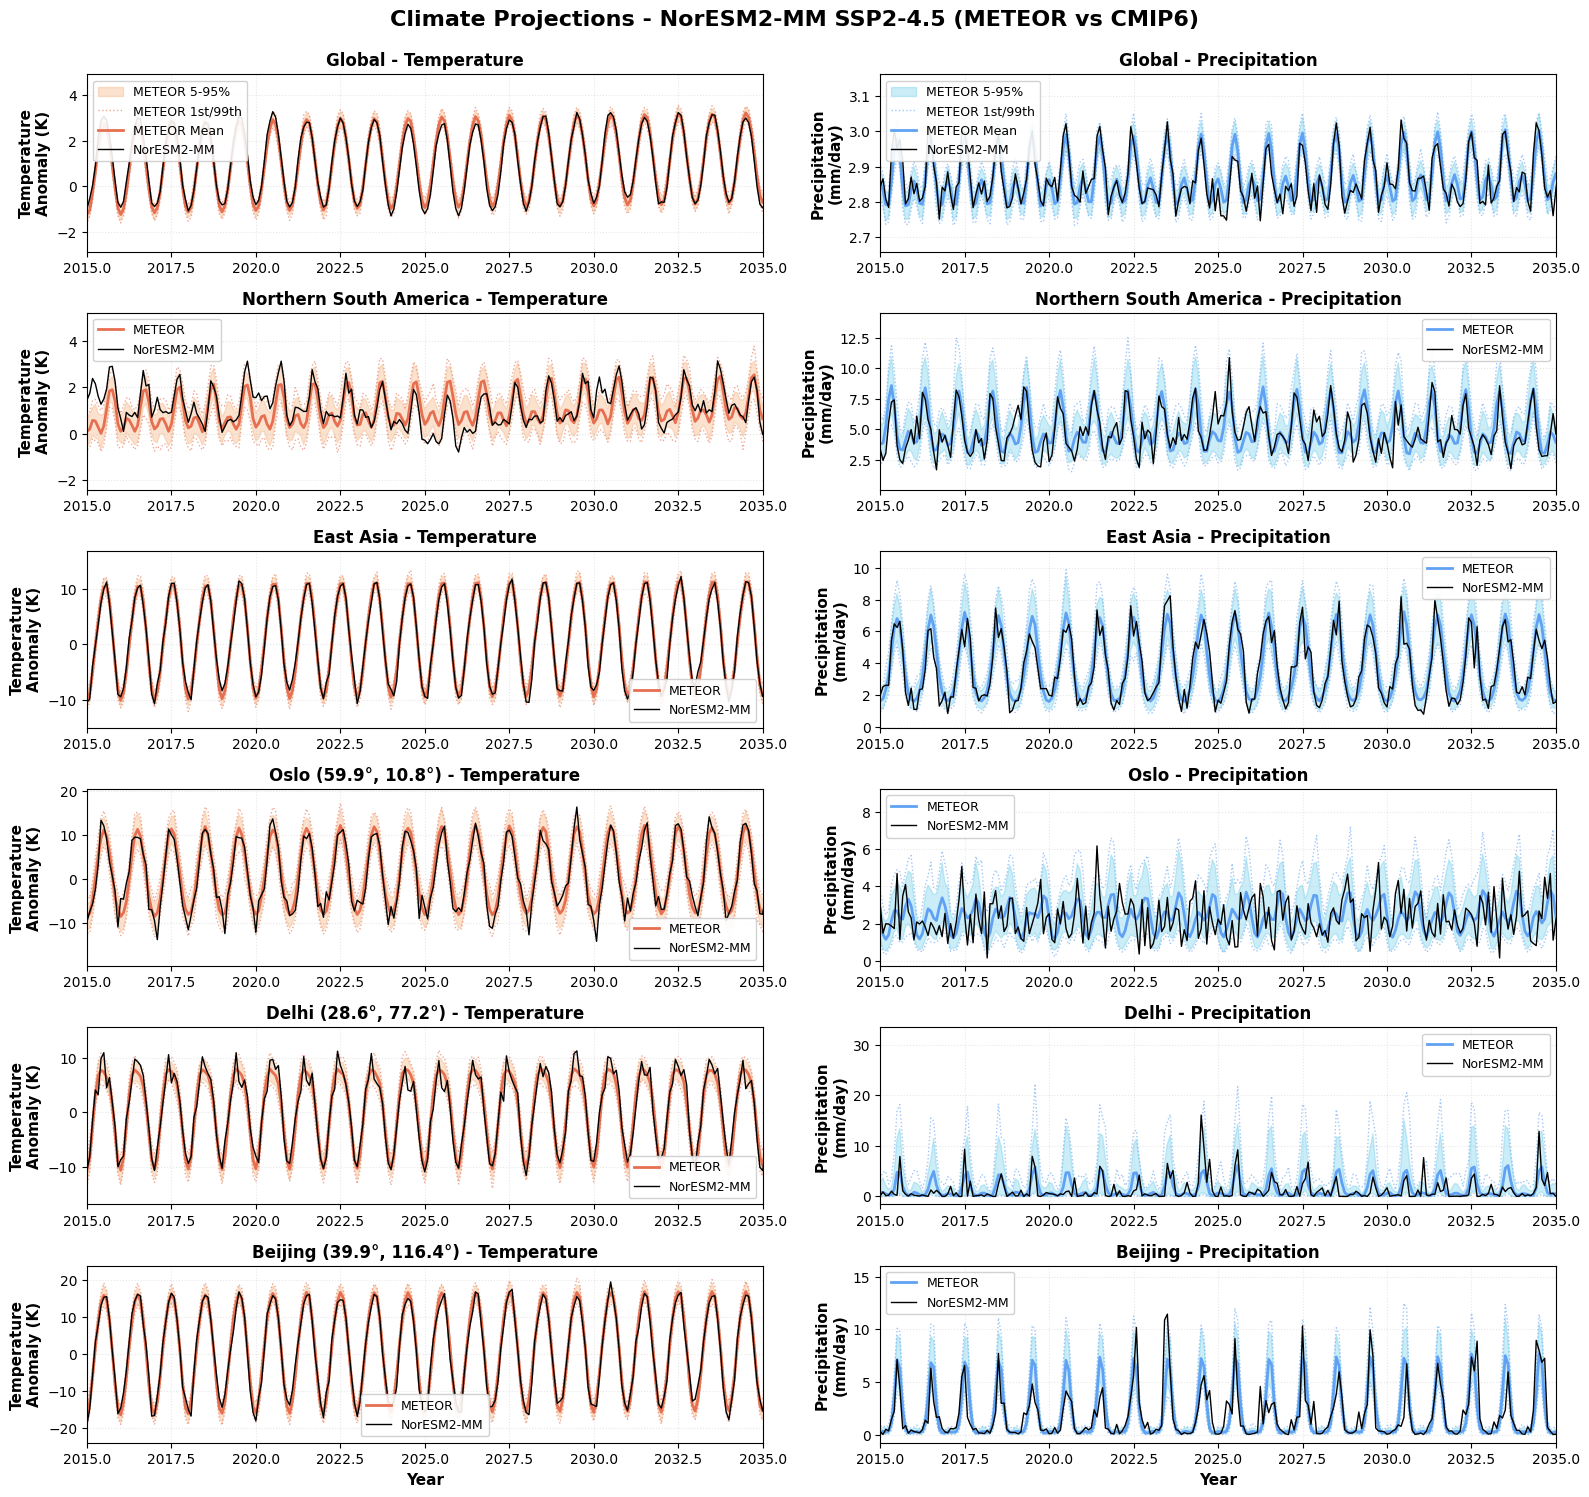

✅ Comprehensive plot complete
   Rows: 1 global + 2 regions + 3 cities = 6 total
   Time range: 2015-2035
   Temperature range: -2.61 to 4.76 K
   Precipitation range: 2.67 to 3.15 mm/day
   Saved to: ../paper/paper_figures/fig1_comprehensive_projections_2015_2035.pdf


In [30]:
# Extract global data
tas_global = ensemble['tas'].timeseries['global']
pr_global = ensemble['pr'].timeseries['global']

# Create time axis (monthly)
n_months = tas_global.shape[1]
years = 1850 + np.arange(n_months) / 12

# Get CMIP6 data (already loaded from earlier cells)
cmip6_tas_global = cmip6_timeseries['tas']['global']
cmip6_pr_global = cmip6_timeseries['pr']['global']

# Create CMIP6 time axis
n_months_cmip6 = cmip6_tas_global.shape[1]
years_cmip6 = 1850 + np.arange(n_months_cmip6) / 12

# Subset for this plot: drop NEU and Cairo
plot_regions = [r for r in regions if r != 'NEU']
plot_cities = {k: v for k, v in cities.items() if k != 'Cairo'}

# Create comprehensive figure: 1 global + 2 regions + 3 cities = 6 rows, 2 columns
n_rows = 1 + len(plot_regions) + len(plot_cities)
fig, axes = plt.subplots(n_rows, 2, figsize=(16, 2.5 * n_rows))
fig.suptitle('Climate Projections - NorESM2-MM SSP2-4.5 (METEOR vs CMIP6)', 
             fontsize=16, fontweight='bold', y=0.995)

row_idx = 0

# === GLOBAL ===
# Temperature (left column)
ax_t = axes[row_idx, 0]
tas_p1 = np.percentile(tas_global, 1, axis=0)
tas_p5 = np.percentile(tas_global, 5, axis=0)
tas_p95 = np.percentile(tas_global, 95, axis=0)
tas_p99 = np.percentile(tas_global, 99, axis=0)
tas_mean = tas_global.mean(axis=0)

# Convert precipitation to mm/day (kg/m²/s * 86400)
pr_global_mmday = pr_global * 86400

ax_t.fill_between(years, tas_p5, tas_p95, color='#F4A261', alpha=0.3, label='METEOR 5-95%')
ax_t.plot(years, tas_p1, color='#E76F51', linewidth=1, linestyle=':', alpha=0.6, label='METEOR 1st/99th')
ax_t.plot(years, tas_p99, color='#E76F51', linewidth=1, linestyle=':', alpha=0.6)
ax_t.plot(years, tas_mean, color='#E76F51', linewidth=2, label='METEOR Mean')

if cmip6_tas_global.ndim == 2:
    cmip6_tas_mean = cmip6_tas_global.mean(dim='ens')
    ax_t.plot(years_cmip6, cmip6_tas_mean, color='black', linestyle='-', linewidth=1, label='NorESM2-MM', zorder=10)
else:
    ax_t.plot(years_cmip6, cmip6_tas_global, color='black', linestyle='-', linewidth=1, label='NorESM2-MM', zorder=10)

ax_t.set_xlim([2015, 2035])
ax_t.set_ylabel('Temperature\nAnomaly (K)', fontsize=11, fontweight='bold')
ax_t.set_title('Global - Temperature', fontsize=12, fontweight='bold')
ax_t.grid(True, alpha=0.3, linestyle=':')
leg = ax_t.legend(fontsize=9, loc='upper left', framealpha=0.9)
leg.set_zorder(100)

# Precipitation (right column)
ax_p = axes[row_idx, 1]
pr_p1 = np.percentile(pr_global_mmday, 1, axis=0)
pr_p5 = np.percentile(pr_global_mmday, 5, axis=0)
pr_p95 = np.percentile(pr_global_mmday, 95, axis=0)
pr_p99 = np.percentile(pr_global_mmday, 99, axis=0)
pr_mean = pr_global_mmday.mean(axis=0)

ax_p.fill_between(years, pr_p5, pr_p95, color='#51C4E7', alpha=0.3, label='METEOR 5-95%')
ax_p.plot(years, pr_p1, color='#61A1F4', linewidth=1, linestyle=':', alpha=0.6, label='METEOR 1st/99th')
ax_p.plot(years, pr_p99, color='#61A1F4', linewidth=1, linestyle=':', alpha=0.6)
ax_p.plot(years, pr_mean, color='#61A1F4', linewidth=2, label='METEOR Mean')

# Convert CMIP6 precipitation to mm/day
if cmip6_pr_global.ndim == 2:
    cmip6_pr_mean = cmip6_pr_global.mean(dim='ens') * 86400
    ax_p.plot(years_cmip6, cmip6_pr_mean, color='black', linestyle='-', linewidth=1, label='NorESM2-MM', zorder=10)
else:
    cmip6_pr_mean = cmip6_pr_global * 86400
    ax_p.plot(years_cmip6, cmip6_pr_mean, color='black', linestyle='-', linewidth=1, label='NorESM2-MM', zorder=10)

ax_p.set_xlim([2015, 2035])
ax_p.set_ylabel('Precipitation\n(mm/day)', fontsize=11, fontweight='bold')
ax_p.set_title('Global - Precipitation', fontsize=12, fontweight='bold')
ax_p.grid(True, alpha=0.3, linestyle=':')
leg = ax_p.legend(fontsize=9, loc='upper left', framealpha=0.9)
leg.set_zorder(100)

row_idx += 1

# === REGIONS (excluding NEU) ===
for region in plot_regions:
    # Get data
    tas_reg = ensemble['tas'].timeseries[f'regional:{region}']
    pr_reg = ensemble['pr'].timeseries[f'regional:{region}']
    
    # Convert precipitation to mm/day
    pr_reg_mmday = pr_reg * 86400
    
    # Get CMIP6 data
    cmip6_tas_reg = cmip6_timeseries['tas'][f'regional:{region}']
    cmip6_pr_reg = cmip6_timeseries['pr'][f'regional:{region}']
    
    # Temperature (left column)
    ax_t = axes[row_idx, 0]
    tas_p1 = np.percentile(tas_reg, 1, axis=0)
    tas_p5 = np.percentile(tas_reg, 5, axis=0)
    tas_p95 = np.percentile(tas_reg, 95, axis=0)
    tas_p99 = np.percentile(tas_reg, 99, axis=0)
    tas_mean = tas_reg.mean(axis=0)
    
    ax_t.fill_between(years, tas_p5, tas_p95, color='#F4A261', alpha=0.3)
    ax_t.plot(years, tas_p1, color='#E76F51', linewidth=1, linestyle=':', alpha=0.6)
    ax_t.plot(years, tas_p99, color='#E76F51', linewidth=1, linestyle=':', alpha=0.6)
    ax_t.plot(years, tas_mean, color='#E76F51', linewidth=2, label='METEOR')
    
    if cmip6_tas_reg.ndim == 2:
        cmip6_tas_mean = cmip6_tas_reg.mean(dim='ens')
        ax_t.plot(years_cmip6, cmip6_tas_mean, color='black', linestyle='-', linewidth=1, label='NorESM2-MM', zorder=10)
    else:
        ax_t.plot(years_cmip6, cmip6_tas_reg, color='black', linestyle='-', linewidth=1, label='NorESM2-MM', zorder=10)
    
    ax_t.set_xlim([2015, 2035])
    ax_t.set_ylabel('Temperature\nAnomaly (K)', fontsize=11, fontweight='bold')
    ax_t.set_title(f'{region_names[region]} - Temperature', fontsize=12, fontweight='bold')
    ax_t.grid(True, alpha=0.3, linestyle=':')
    leg = ax_t.legend(fontsize=9, loc='best', framealpha=0.9)
    leg.set_zorder(100)
    
    # Precipitation (right column)
    ax_p = axes[row_idx, 1]
    pr_p1 = np.percentile(pr_reg_mmday, 1, axis=0)
    pr_p5 = np.percentile(pr_reg_mmday, 5, axis=0)
    pr_p95 = np.percentile(pr_reg_mmday, 95, axis=0)
    pr_p99 = np.percentile(pr_reg_mmday, 99, axis=0)
    pr_mean = pr_reg_mmday.mean(axis=0)
    
    ax_p.fill_between(years, pr_p5, pr_p95, color='#51C4E7', alpha=0.3)
    ax_p.plot(years, pr_p1, color='#61A1F4', linewidth=1, linestyle=':', alpha=0.6)
    ax_p.plot(years, pr_p99, color='#61A1F4', linewidth=1, linestyle=':', alpha=0.6)
    ax_p.plot(years, pr_mean, color='#61A1F4', linewidth=2, label='METEOR')
    
    if cmip6_pr_reg.ndim == 2:
        cmip6_pr_mean = cmip6_pr_reg.mean(dim='ens') * 86400
        ax_p.plot(years_cmip6, cmip6_pr_mean, color='black', linestyle='-', linewidth=1, label='NorESM2-MM', zorder=10)
    else:
        cmip6_pr_mean = cmip6_pr_reg * 86400
        ax_p.plot(years_cmip6, cmip6_pr_mean, color='black', linestyle='-', linewidth=1, label='NorESM2-MM', zorder=10)
    
    ax_p.set_xlim([2015, 2035])
    ax_p.set_ylabel('Precipitation\n(mm/day)', fontsize=11, fontweight='bold')
    ax_p.set_title(f'{region_names[region]} - Precipitation', fontsize=12, fontweight='bold')
    ax_p.grid(True, alpha=0.3, linestyle=':')
    leg = ax_p.legend(fontsize=9, loc='best', framealpha=0.9)
    leg.set_zorder(100)
    
    row_idx += 1

# === CITIES (excluding Cairo) ===
# Load CMIP6 SSP245 point data for cities (both tas and pr)
cmip6_ssp245_data = data_getter.make_meteor_training_data(
    "ssp245", emulator.model, monthly=True
)
cmip6_ssp245_full = cmip6_ssp245_data['tas']
cmip6_ssp245_pr_full = cmip6_ssp245_data['pr']

cmip6_picontrol_data = data_getter.make_meteor_training_data(
    "piControl", emulator.model, monthly=True
)
cmip6_picontrol_full = cmip6_picontrol_data['tas']
cmip6_picontrol_pr_full = cmip6_picontrol_data['pr']

# Create time axis for SSP245 data (2015-2100)
n_months_ssp245 = cmip6_ssp245_full.shape[1]
years_ssp245 = 2015 + np.arange(n_months_ssp245) / 12

city_list = list(plot_cities.keys())
for city in city_list:
    # Build point key
    point_key = f"point:{plot_cities[city]['lat']},{plot_cities[city]['lon']}"
    
    # Get METEOR data
    tas_city = ensemble['tas'].timeseries[point_key]
    pr_city = ensemble['pr'].timeseries[point_key]
    
    # Convert precipitation to mm/day
    pr_city_mmday = pr_city * 86400
    
    # Get CMIP6 point data for this city (temperature and precipitation)
    cmip6_tas_point = geo_data_utils.extract_point(cmip6_ssp245_full, plot_cities[city]['lat'], plot_cities[city]['lon'])
    picontrol_tas_point = geo_data_utils.extract_point(cmip6_picontrol_full, plot_cities[city]['lat'], plot_cities[city]['lon'])
    baseline_tas = float(picontrol_tas_point.mean().values)
    
    # Convert to anomaly
    cmip6_tas_city_anom = cmip6_tas_point - baseline_tas
    
    # Get CMIP6 precipitation point data
    cmip6_pr_point = geo_data_utils.extract_point(cmip6_ssp245_pr_full, plot_cities[city]['lat'], plot_cities[city]['lon'])
    picontrol_pr_point = geo_data_utils.extract_point(cmip6_picontrol_pr_full, plot_cities[city]['lat'], plot_cities[city]['lon'])
    
    # Temperature (left column)
    ax_t = axes[row_idx, 0]
    tas_p1 = np.percentile(tas_city, 1, axis=0)
    tas_p5 = np.percentile(tas_city, 5, axis=0)
    tas_p95 = np.percentile(tas_city, 95, axis=0)
    tas_p99 = np.percentile(tas_city, 99, axis=0)
    tas_mean = tas_city.mean(axis=0)
    
    ax_t.fill_between(years, tas_p5, tas_p95, color='#F4A261', alpha=0.3)
    ax_t.plot(years, tas_p1, color='#E76F51', linewidth=1, linestyle=':', alpha=0.6)
    ax_t.plot(years, tas_p99, color='#E76F51', linewidth=1, linestyle=':', alpha=0.6)
    ax_t.plot(years, tas_mean, color='#E76F51', linewidth=2, label='METEOR')
    
    # Plot CMIP6 data with correct time axis
    if cmip6_tas_city_anom.ndim == 2:
        cmip6_tas_mean = cmip6_tas_city_anom.mean(dim='ens')
        ax_t.plot(years_ssp245, cmip6_tas_mean, color='black', linestyle='-', linewidth=1, label='NorESM2-MM', zorder=10)
    else:
        ax_t.plot(years_ssp245, cmip6_tas_city_anom, color='black', linestyle='-', linewidth=1, label='NorESM2-MM', zorder=10)
    
    ax_t.set_xlim([2015, 2035])
    ax_t.set_ylabel('Temperature\nAnomaly (K)', fontsize=11, fontweight='bold')
    ax_t.set_title(f'{city} ({plot_cities[city]["lat"]:.1f}°, {plot_cities[city]["lon"]:.1f}°) - Temperature', 
                   fontsize=12, fontweight='bold')
    ax_t.grid(True, alpha=0.3, linestyle=':')
    leg = ax_t.legend(fontsize=9, loc='best', framealpha=0.9)
    leg.set_zorder(100)
    
    # Precipitation (right column)
    ax_p = axes[row_idx, 1]
    pr_p1 = np.percentile(pr_city_mmday, 1, axis=0)
    pr_p5 = np.percentile(pr_city_mmday, 5, axis=0)
    pr_p95 = np.percentile(pr_city_mmday, 95, axis=0)
    pr_p99 = np.percentile(pr_city_mmday, 99, axis=0)
    pr_mean = pr_city_mmday.mean(axis=0)
    
    ax_p.fill_between(years, pr_p5, pr_p95, color='#51C4E7', alpha=0.3)
    ax_p.plot(years, pr_p1, color='#61A1F4', linewidth=1, linestyle=':', alpha=0.6)
    ax_p.plot(years, pr_p99, color='#61A1F4', linewidth=1, linestyle=':', alpha=0.6)
    ax_p.plot(years, pr_mean, color='#61A1F4', linewidth=2, label='METEOR')
    
    # Plot CMIP6 precipitation data with correct time axis and convert to mm/day
    if cmip6_pr_point.ndim == 2:
        cmip6_pr_mean = cmip6_pr_point.mean(dim='ens') * 86400
        ax_p.plot(years_ssp245, cmip6_pr_mean, color='black', linestyle='-', linewidth=1, label='NorESM2-MM', zorder=10)
    else:
        cmip6_pr_city_mmday = cmip6_pr_point * 86400
        ax_p.plot(years_ssp245, cmip6_pr_city_mmday, color='black', linestyle='-', linewidth=1, label='NorESM2-MM', zorder=10)
    
    ax_p.set_xlim([2015, 2035])
    ax_p.set_ylabel('Precipitation\n(mm/day)', fontsize=11, fontweight='bold')
    ax_p.set_title(f'{city} - Precipitation', fontsize=12, fontweight='bold')
    ax_p.grid(True, alpha=0.3, linestyle=':')
    leg = ax_p.legend(fontsize=9, loc='best', framealpha=0.9)
    leg.set_zorder(100)
    
    row_idx += 1

# Add x-label to bottom row
axes[-1, 0].set_xlabel('Year', fontsize=11, fontweight='bold')
axes[-1, 1].set_xlabel('Year', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'fig1_comprehensive_projections_2015_2035.pdf'), bbox_inches='tight', dpi=300)
plt.show()

print(f"✅ Comprehensive plot complete")
print(f"   Rows: 1 global + {len(plot_regions)} regions + {len(plot_cities)} cities = {n_rows} total")
print(f"   Time range: 2015-2035")
print(f"   Temperature range: {float(tas_global.min()):.2f} to {float(tas_global.max()):.2f} K")
print(f"   Precipitation range: {float(pr_global_mmday.min()):.2f} to {float(pr_global_mmday.max()):.2f} mm/day")
print(f"   Saved to: {os.path.join(FIGURE_DIR, 'fig1_comprehensive_projections_2015_2035.pdf')}")

## 6. Plot 2: Regional Temperature and Precipitation

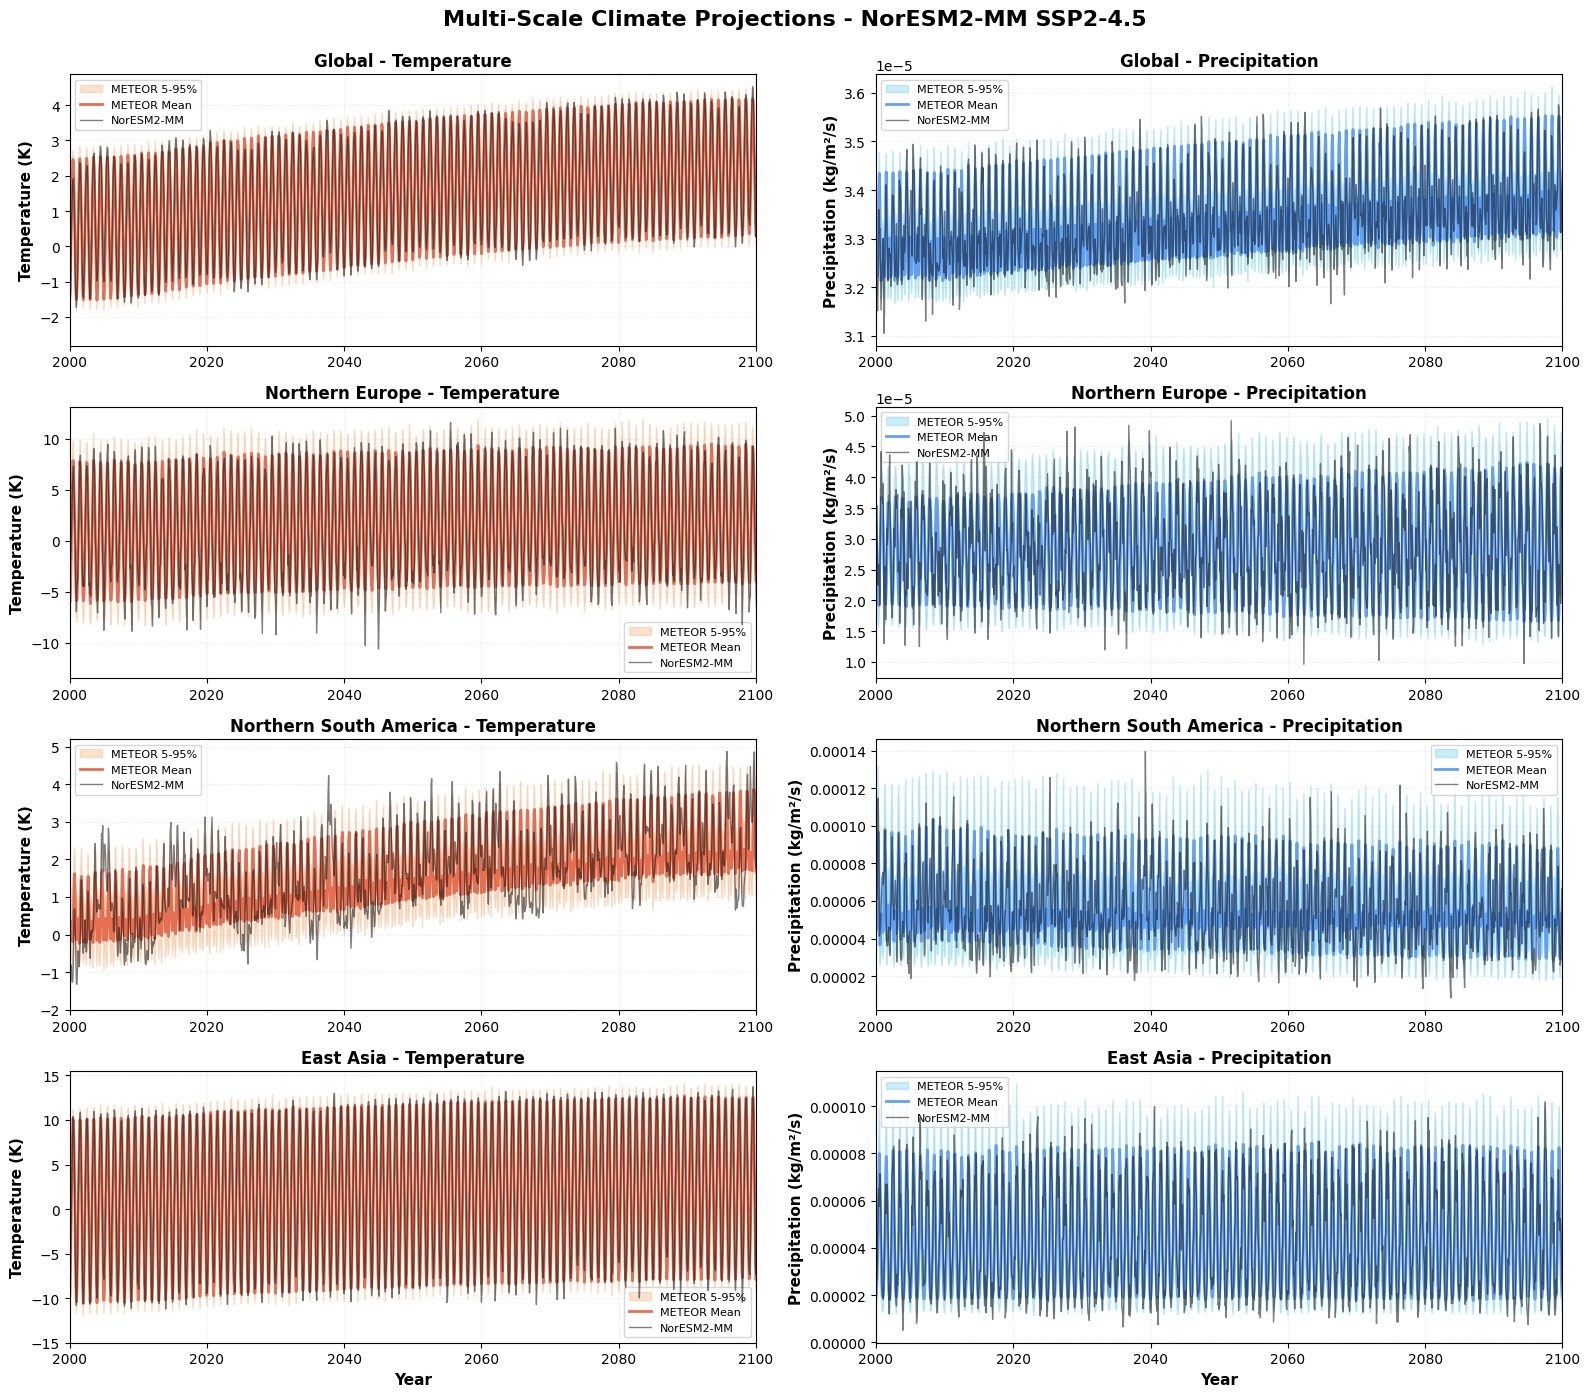

   Saved to: ../paper/paper_figures/fig2_regional_projections_2000_2100.pdf


In [10]:
# Create 4x2 grid (1 global + 3 regions, temp + precip)
fig, axes = plt.subplots(4, 2, figsize=(16, 14))
fig.suptitle('Multi-Scale Climate Projections - NorESM2-MM SSP2-4.5', 
             fontsize=16, fontweight='bold', y=0.995)

# === GLOBAL (row 0) ===
tas_global_data = ensemble['tas'].timeseries['global']
pr_global_data = ensemble['pr'].timeseries['global']
cmip6_tas_global_data = cmip6_timeseries['tas']['global']
cmip6_pr_global_data = cmip6_timeseries['pr']['global']

# Temperature (left column)
ax_t = axes[0, 0]
tas_p5 = np.percentile(tas_global_data, 5, axis=0)
tas_p95 = np.percentile(tas_global_data, 95, axis=0)
tas_mean = tas_global_data.mean(axis=0)

ax_t.fill_between(years, tas_p5, tas_p95, color='#F4A261', alpha=0.3, label='METEOR 5-95%')
ax_t.plot(years, tas_mean, color='#E76F51', linewidth=2, label='METEOR Mean')

# Plot CMIP6 overlay
if cmip6_tas_global_data.ndim == 2:
    cmip6_tas_mean = cmip6_tas_global_data.mean(dim='ens')
    ax_t.plot(years_cmip6, cmip6_tas_mean, color='black', linestyle='-', linewidth=1, label='NorESM2-MM', zorder=10, alpha=0.5)
else:
    ax_t.plot(years_cmip6, cmip6_tas_global_data, color='black', linestyle='-', linewidth=1, label='NorESM2-MM', zorder=10, alpha=0.5)

ax_t.set_ylabel('Temperature (K)', fontsize=11, fontweight='bold')
ax_t.set_title('Global - Temperature', fontsize=12, fontweight='bold')
ax_t.grid(True, alpha=0.3, linestyle=':')
ax_t.legend(fontsize=8, loc='best')
ax_t.set_xlim([2000, 2100])

# Precipitation (right column)
ax_p = axes[0, 1]
pr_p5 = np.percentile(pr_global_data, 5, axis=0)
pr_p95 = np.percentile(pr_global_data, 95, axis=0)
pr_mean = pr_global_data.mean(axis=0)

ax_p.fill_between(years, pr_p5, pr_p95, color='#51C4E7', alpha=0.3, label='METEOR 5-95%')
ax_p.plot(years, pr_mean, color='#61A1F4', linewidth=2, label='METEOR Mean')

# Plot CMIP6 overlay
if cmip6_pr_global_data.ndim == 2:
    cmip6_pr_mean = cmip6_pr_global_data.mean(dim='ens')
    ax_p.plot(years_cmip6, cmip6_pr_mean, color='black', linestyle='-', linewidth=1, label='NorESM2-MM', zorder=10, alpha=0.5)
else:
    ax_p.plot(years_cmip6, cmip6_pr_global_data, color='black', linestyle='-', linewidth=1, label='NorESM2-MM', zorder=10, alpha=0.5)

ax_p.set_ylabel('Precipitation (kg/m²/s)', fontsize=11, fontweight='bold')
ax_p.set_title('Global - Precipitation', fontsize=12, fontweight='bold')
ax_p.grid(True, alpha=0.3, linestyle=':')
ax_p.legend(fontsize=8, loc='best')
ax_p.set_xlim([2000, 2100])

# === REGIONS (rows 1-3) ===
for i, region in enumerate(regions, start=1):
    # Get data
    tas_reg = ensemble['tas'].timeseries[f'regional:{region}']
    pr_reg = ensemble['pr'].timeseries[f'regional:{region}']
    cmip6_tas_reg = cmip6_timeseries['tas'][f'regional:{region}']
    cmip6_pr_reg = cmip6_timeseries['pr'][f'regional:{region}']
    
    # Temperature (left column)
    ax_t = axes[i, 0]
    tas_p5 = np.percentile(tas_reg, 5, axis=0)
    tas_p95 = np.percentile(tas_reg, 95, axis=0)
    tas_mean = tas_reg.mean(axis=0)
    
    ax_t.fill_between(years, tas_p5, tas_p95, color='#F4A261', alpha=0.3, label='METEOR 5-95%')
    ax_t.plot(years, tas_mean, color='#E76F51', linewidth=2, label='METEOR Mean')
    
    # Plot CMIP6 overlay
    if cmip6_tas_reg.ndim == 2:
        cmip6_tas_mean = cmip6_tas_reg.mean(dim='ens')
        ax_t.plot(years_cmip6, cmip6_tas_mean, color='black', linestyle='-', linewidth=1, label='NorESM2-MM', zorder=10, alpha=0.5)
    else:
        ax_t.plot(years_cmip6, cmip6_tas_reg, color='black', linestyle='-', linewidth=1, label='NorESM2-MM', zorder=10, alpha=0.5)
    
    ax_t.set_ylabel('Temperature (K)', fontsize=11, fontweight='bold')
    ax_t.set_title(f"{region_names[region]} - Temperature", fontsize=12, fontweight='bold')
    ax_t.grid(True, alpha=0.3, linestyle=':')
    ax_t.legend(fontsize=8, loc='best')
    ax_t.set_xlim([2000, 2100])

    
    # Precipitation (right column)
    ax_p = axes[i, 1]
    pr_p5 = np.percentile(pr_reg, 5, axis=0)
    pr_p95 = np.percentile(pr_reg, 95, axis=0)
    pr_mean = pr_reg.mean(axis=0)
    
    ax_p.fill_between(years, pr_p5, pr_p95, color='#51C4E7', alpha=0.3, label='METEOR 5-95%')
    ax_p.plot(years, pr_mean, color='#61A1F4', linewidth=2, label='METEOR Mean')
    
    # Plot CMIP6 overlay
    if cmip6_pr_reg.ndim == 2:
        cmip6_pr_mean = cmip6_pr_reg.mean(dim='ens')
        ax_p.plot(years_cmip6, cmip6_pr_mean, color='black', linestyle='-', linewidth=1, label='NorESM2-MM', zorder=10, alpha=0.5)
    else:
        ax_p.plot(years_cmip6, cmip6_pr_reg, color='black', linestyle='-', linewidth=1, label='NorESM2-MM', zorder=10, alpha=0.5)
    
    ax_p.set_ylabel('Precipitation (kg/m²/s)', fontsize=11, fontweight='bold')
    ax_p.set_title(f"{region_names[region]} - Precipitation", fontsize=12, fontweight='bold')
    ax_p.grid(True, alpha=0.3, linestyle=':')
    ax_p.legend(fontsize=8, loc='best')
    ax_p.set_xlim([2000, 2100])

    
    if i == 3:
        ax_t.set_xlabel('Year', fontsize=11, fontweight='bold')
        ax_p.set_xlabel('Year', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'fig2_regional_projections_2000_2100.pdf'), bbox_inches='tight', dpi=300)
plt.show()
print(f"   Saved to: {os.path.join(FIGURE_DIR, 'fig2_regional_projections_2000_2100.pdf')}")

## 7. Plot 3: City-Scale Temperature and Precipitation

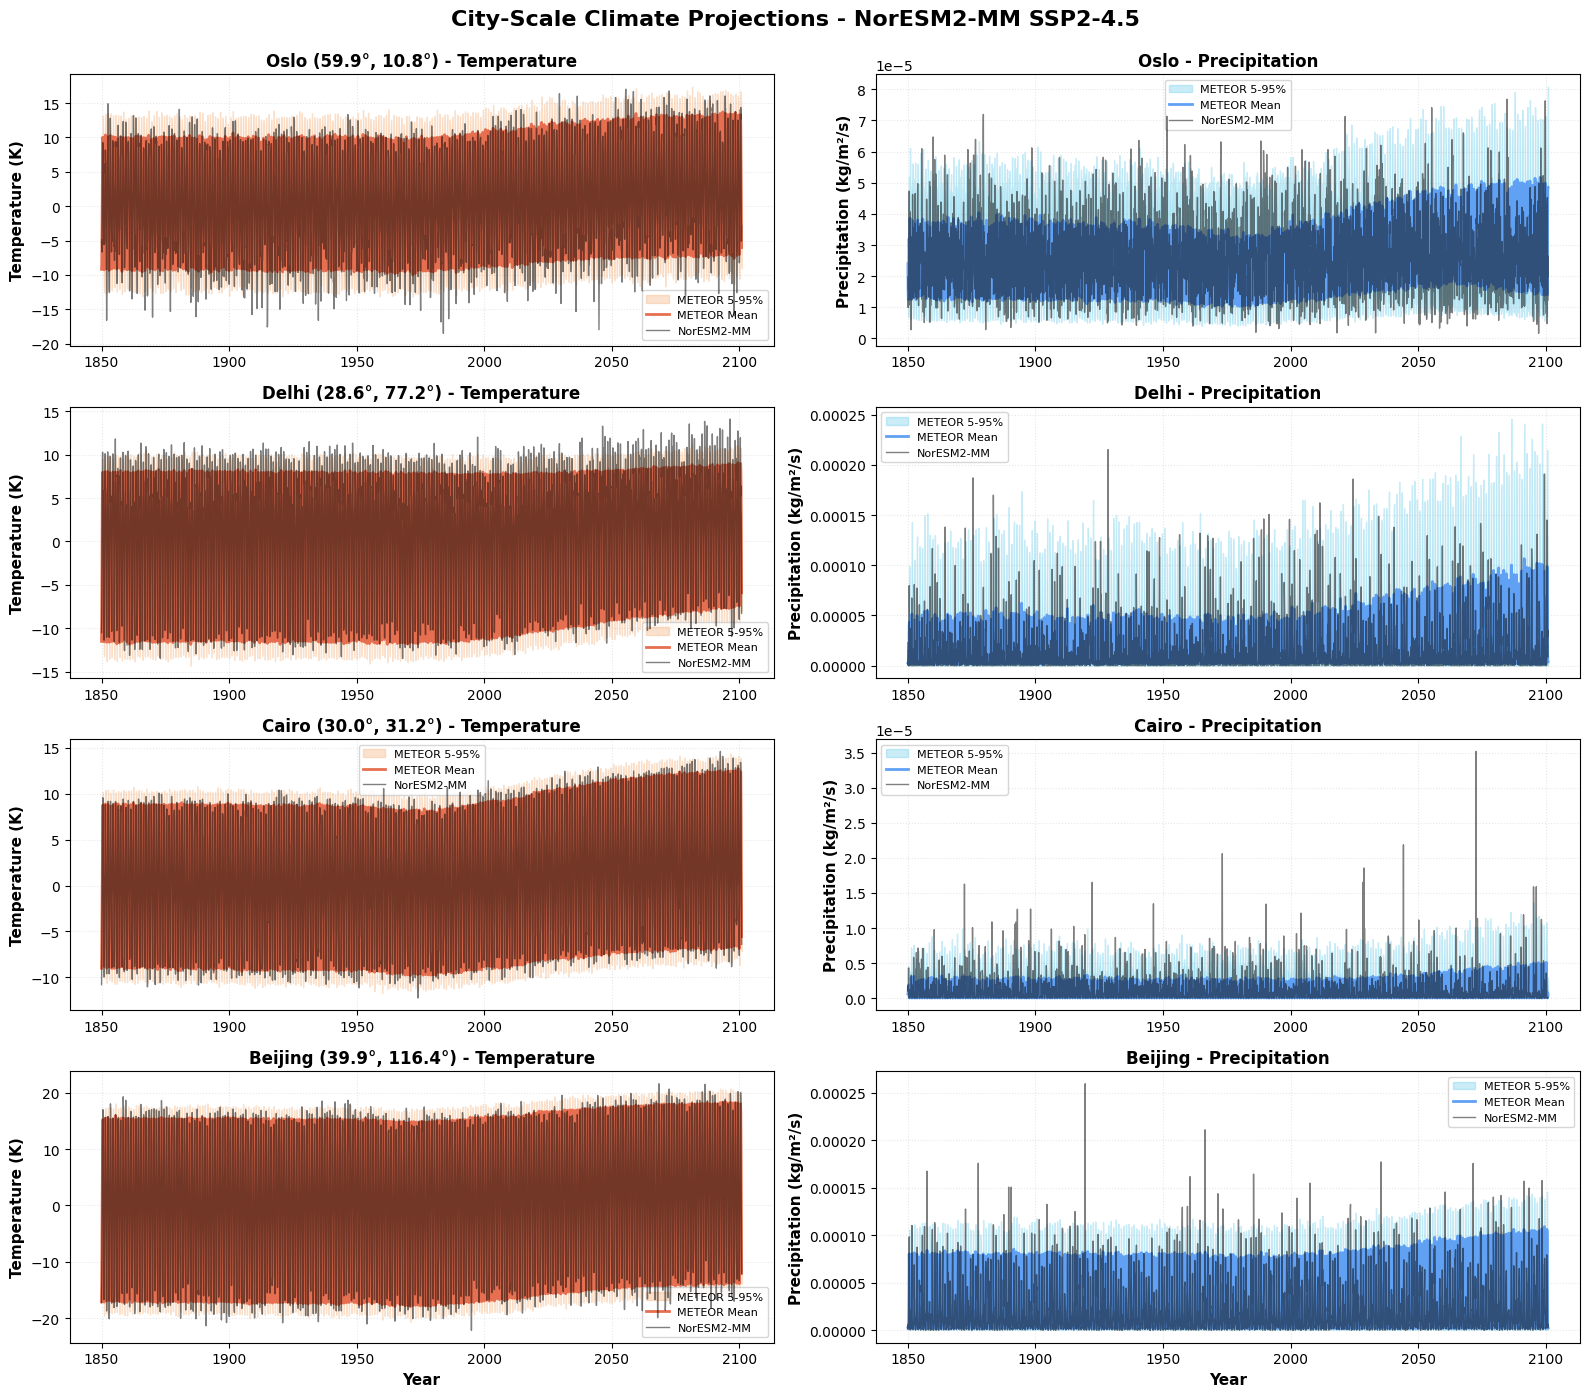

   Saved to: ../paper/paper_figures/fig3_city_projections_1850_2100.pdf


In [11]:
# Create 4x2 grid (4 cities, temp + precip)
fig, axes = plt.subplots(4, 2, figsize=(16, 14))
fig.suptitle('City-Scale Climate Projections - NorESM2-MM SSP2-4.5', 
             fontsize=16, fontweight='bold', y=0.995)

city_list = list(cities.keys())

# Load CMIP6 composite data (historical + SSP245) for cities
cmip6_composite_data = data_getter.make_meteor_training_data_composite(
    ["historical", "ssp245"], emulator.model, monthly=True
)
cmip6_composite_full = cmip6_composite_data['tas']
cmip6_composite_pr_full = cmip6_composite_data['pr']

# Create time axis for composite data (1850-2100)
n_months_composite = cmip6_composite_full.shape[1]
years_composite = 1850 + np.arange(n_months_composite) / 12

for i, city in enumerate(city_list):
    # Build point key
    point_key = f"point:{cities[city]['lat']},{cities[city]['lon']}"
    
    # Get METEOR data
    tas_city = ensemble['tas'].timeseries[point_key]
    pr_city = ensemble['pr'].timeseries[point_key]
    
    # Get CMIP6 point data for this city (using composite historical+SSP245)
    cmip6_tas_point = geo_data_utils.extract_point(cmip6_composite_full, cities[city]['lat'], cities[city]['lon'])
    picontrol_tas_point = geo_data_utils.extract_point(cmip6_picontrol_full, cities[city]['lat'], cities[city]['lon'])
    baseline_tas = float(picontrol_tas_point.mean().values)
    cmip6_tas_city_anom = cmip6_tas_point - baseline_tas
    
    cmip6_pr_point = geo_data_utils.extract_point(cmip6_composite_pr_full, cities[city]['lat'], cities[city]['lon'])
    
    # Temperature (left column)
    ax_t = axes[i, 0]
    
    # Calculate percentiles and mean
    tas_p5 = np.percentile(tas_city, 5, axis=0)
    tas_p95 = np.percentile(tas_city, 95, axis=0)
    tas_mean = tas_city.mean(axis=0)
    
    # Plot shaded region and mean
    ax_t.fill_between(years, tas_p5, tas_p95, color='#F4A261', alpha=0.3, label='METEOR 5-95%')
    ax_t.plot(years, tas_mean, color='#E76F51', linewidth=2, label='METEOR Mean')
    
    # Plot CMIP6 overlay (now includes historical period) with alpha=0.5
    if cmip6_tas_city_anom.ndim == 2:
        cmip6_tas_mean = cmip6_tas_city_anom.mean(dim='ens')
        ax_t.plot(years_composite, cmip6_tas_mean, color='black', linestyle='-', linewidth=1, label='NorESM2-MM', zorder=10, alpha=0.5)
    else:
        ax_t.plot(years_composite, cmip6_tas_city_anom, color='black', linestyle='-', linewidth=1, label='NorESM2-MM', zorder=10, alpha=0.5)
    
    ax_t.set_ylabel('Temperature (K)', fontsize=11, fontweight='bold')
    ax_t.set_title(f"{city} ({cities[city]['lat']:.1f}°, {cities[city]['lon']:.1f}°) - Temperature", 
                   fontsize=12, fontweight='bold')
    ax_t.grid(True, alpha=0.3, linestyle=':')
    ax_t.legend(fontsize=8, loc='best')
    if i == 3:
        ax_t.set_xlabel('Year', fontsize=11, fontweight='bold')
    
    # Precipitation (right column)
    ax_p = axes[i, 1]
    
    # Calculate percentiles and mean
    pr_p5 = np.percentile(pr_city, 5, axis=0)
    pr_p95 = np.percentile(pr_city, 95, axis=0)
    pr_mean = pr_city.mean(axis=0)
    
    # Plot shaded region and mean
    ax_p.fill_between(years, pr_p5, pr_p95, color='#51C4E7', alpha=0.3, label='METEOR 5-95%')
    ax_p.plot(years, pr_mean, color='#61A1F4', linewidth=2, label='METEOR Mean')
    
    # Plot CMIP6 overlay (now includes historical period) with alpha=0.5
    if cmip6_pr_point.ndim == 2:
        cmip6_pr_mean = cmip6_pr_point.mean(dim='ens')
        ax_p.plot(years_composite, cmip6_pr_mean, color='black', linestyle='-', linewidth=1, label='NorESM2-MM', zorder=10, alpha=0.5)
    else:
        ax_p.plot(years_composite, cmip6_pr_point, color='black', linestyle='-', linewidth=1, label='NorESM2-MM', zorder=10, alpha=0.5)
    
    ax_p.set_ylabel('Precipitation (kg/m²/s)', fontsize=11, fontweight='bold')
    ax_p.set_title(f"{city} - Precipitation", fontsize=12, fontweight='bold')
    ax_p.grid(True, alpha=0.3, linestyle=':')
    ax_p.legend(fontsize=8, loc='best')
    if i == 3:
        ax_p.set_xlabel('Year', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'fig3_city_projections_1850_2100.pdf'), bbox_inches='tight', dpi=300)
plt.show()
print(f"   Saved to: {os.path.join(FIGURE_DIR, 'fig3_city_projections_1850_2100.pdf')}")

## 8. Ensemble Adequacy Test

Test if 100 realizations are sufficient by comparing statistics from different ensemble subsets.
We'll test for each region, for both temperature and precipitation.

In [12]:
def ensemble_adequacy_test(data, n_tests=20, subset_size=50):
    """
    Test ensemble adequacy by comparing statistics from random subsets.
    
    Returns:
        mean_std: Standard deviation of means from different subsets
        std_std: Standard deviation of stds from different subsets
    """
    n_realizations = data.shape[0]
    
    subset_means = []
    subset_stds = []
    
    for _ in range(n_tests):   
        # Random subset
        idx = np.random.choice(n_realizations, subset_size, replace=False)
        subset = data[idx, :]
           
        subset_means.append(float(subset.mean()))
        subset_stds.append(float(subset.std()))
    
    return np.std(subset_means), np.std(subset_stds)

print("Testing ensemble adequacy (100 realizations, 20 tests with 50-member subsets)...\n")
 
print("GLOBAL:")
tas_mean_std, tas_std_std = ensemble_adequacy_test(ensemble['tas'].timeseries['global'])
pr_mean_std, pr_std_std = ensemble_adequacy_test(ensemble['pr'].timeseries['global'])
print(f"  TAS - Mean variability: {tas_mean_std:.4f}, Std variability: {tas_std_std:.4f}")
print(f"  PR  - Mean variability: {pr_mean_std:.6f}, Std variability: {pr_std_std:.6f}")

# Test for each region
for region in regions:
    print(f"\n{region_names[region].upper()}:")
    tas_data = ensemble['tas'].timeseries[f'regional:{region}']
    pr_data = ensemble['pr'].timeseries[f'regional:{region}']
    
    tas_mean_std, tas_std_std = ensemble_adequacy_test(tas_data)
    pr_mean_std, pr_std_std = ensemble_adequacy_test(pr_data)
    
    print(f"  TAS - Mean variability: {tas_mean_std:.4f}, Std variability: {tas_std_std:.4f}")
    print(f"  PR  - Mean variability: {pr_mean_std:.6f}, Std variability: {pr_std_std:.6f}")

print("\n✅ Low variability indicates sufficient ensemble size")

Testing ensemble adequacy (100 realizations, 20 tests with 50-member subsets)...

GLOBAL:
  TAS - Mean variability: 0.0004, Std variability: 0.0002
  PR  - Mean variability: 0.000000, Std variability: 0.000000

NORTHERN EUROPE:
  TAS - Mean variability: 0.0031, Std variability: 0.0018
  PR  - Mean variability: 0.000000, Std variability: 0.000000

NORTHERN SOUTH AMERICA:
  TAS - Mean variability: 0.0005, Std variability: 0.0006
  PR  - Mean variability: 0.000000, Std variability: 0.000000

EAST ASIA:
  TAS - Mean variability: 0.0010, Std variability: 0.0016
  PR  - Mean variability: 0.000000, Std variability: 0.000000

✅ Low variability indicates sufficient ensemble size


Computing rank histograms for TAS and PR...


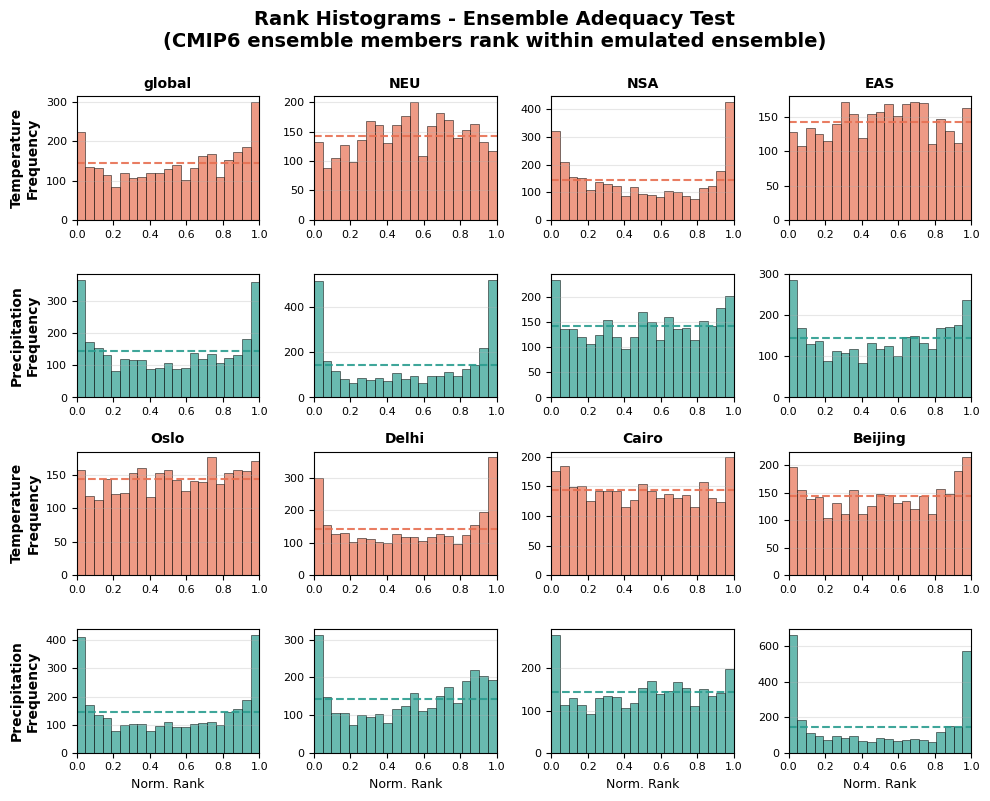


✅ Rank histograms complete

💡 Interpretation:
   - Histogram near uniform line → Emulated ensemble adequately spans CMIP6 variability
   - U-shaped distribution → Under-dispersed (emulated ensemble too narrow)
   - Dome-shaped distribution → Over-dispersed (emulated ensemble too wide)
   - Top row: Temperature (#E76F51), Bottom row: Precipitation (#2A9D8F)
   Saved to: ../paper/paper_figures/fig4_rank_histograms.pdf


In [13]:
# Rank Histogram Analysis - Temperature and Precipitation Separate
print("Computing rank histograms for TAS and PR...")

# Define locations separately
global_regional_locs = ['global', 'regional:NEU', 'regional:NSA', 'regional:EAS']
point_locs = [f"point:{cities[c]['lat']},{cities[c]['lon']}" for c in cities.keys()]

# Create figure: 4 rows (2 for global/regional, 2 for points) x 4 locations
fig, axes = plt.subplots(4, 4, figsize=(10, 8))
fig.suptitle('Rank Histograms - Ensemble Adequacy Test\n(CMIP6 ensemble members rank within emulated ensemble)', 
             fontsize=14, fontweight='bold', y=0.995)

n_bins = 21  # Number of bins for rank histogram

def calculate_ranks(emulated_data, cmip6_data):
    """Calculate normalized ranks for CMIP6 data within emulated ensemble."""
    n_realizations = emulated_data.shape[0]
    n_time_emulated = emulated_data.shape[1]
    
    if cmip6_data.values.ndim == 2:
        cmip6_subset = cmip6_data.values[:, -n_time_emulated:]
        n_ens = cmip6_subset.shape[0]
    else:
        cmip6_subset = cmip6_data.values[-n_time_emulated:][None, :]
        n_ens = 1
    
    ranks = []
    for ens_idx in range(n_ens):
        for t in range(cmip6_subset.shape[1]):
            ensemble_at_t = emulated_data[:, t]
            cmip6_value = float(cmip6_subset[ens_idx, t])
            count_below = np.sum(ensemble_at_t < cmip6_value)
            normalized_rank = count_below / n_realizations
            ranks.append(normalized_rank)
    
    return ranks

# Process global/regional locations (rows 0-1)
for col_idx, loc in enumerate(global_regional_locs):
    for var_idx, (variable, color) in enumerate([('tas', '#E76F51'), ('pr', '#2A9D8F')]):
        ax = axes[var_idx, col_idx]
        
        # Get CMIP6 data
        cmip6_data = cmip6_timeseries[variable][loc]
        
        # Calculate ranks
        ranks = calculate_ranks(ensemble[variable].timeseries[loc], cmip6_data)
        
        # Plot histogram
        counts, bins, patches = ax.hist(ranks, bins=n_bins, range=(0, 1), 
                                        color=color, alpha=0.7, edgecolor='black', linewidth=0.5)
        
        # Add uniform distribution reference line
        expected_count = len(ranks) / n_bins
        ax.axhline(expected_count, color=color, linestyle='--', linewidth=1.5, alpha=0.9)
        
        # Formatting
        if var_idx == 0:  # Temperature row
            label = f"{loc.split(':')[1] if ':' in loc else loc}"
            ax.set_title(label, fontsize=10, fontweight='bold')
        
        # Y-axis label
        if col_idx == 0:
            var_label = 'Temperature' if variable == 'tas' else 'Precipitation'
            ax.set_ylabel(f'{var_label}\nFrequency', fontsize=10, fontweight='bold')
        
        ax.grid(True, alpha=0.3, axis='y')
        ax.set_xlim([0, 1])
        ax.tick_params(axis='both', labelsize=8)

# Process point locations (rows 2-3)
for col_idx, loc in enumerate(point_locs):
    city_name = list(cities.keys())[col_idx]
    
    for var_idx, (variable, color) in enumerate([('tas', '#E76F51'), ('pr', '#2A9D8F')]):
        ax = axes[var_idx + 2, col_idx]  # +2 to place in rows 2-3
        
        # Get CMIP6 data
        cmip6_data = cmip6_tas_point_data[loc] if variable == 'tas' else cmip6_pr_point_data[loc]
        
        # Calculate ranks
        ranks = calculate_ranks(ensemble[variable].timeseries[loc], cmip6_data)
        
        # Plot histogram
        counts, bins, patches = ax.hist(ranks, bins=n_bins, range=(0, 1), 
                                        color=color, alpha=0.7, edgecolor='black', linewidth=0.5)
        
        # Add uniform distribution reference line
        expected_count = len(ranks) / n_bins
        ax.axhline(expected_count, color=color, linestyle='--', linewidth=1.5, alpha=0.9)
        
        # Formatting
        if var_idx == 0:  # Temperature row
            ax.set_title(city_name, fontsize=10, fontweight='bold')
        
        # Y-axis label
        if col_idx == 0:
            var_label = 'Temperature' if variable == 'tas' else 'Precipitation'
            ax.set_ylabel(f'{var_label}\nFrequency', fontsize=10, fontweight='bold')
        
        # X-axis label only on bottom row
        if var_idx == 1:
            ax.set_xlabel('Norm. Rank', fontsize=9)
        
        ax.grid(True, alpha=0.3, axis='y')
        ax.set_xlim([0, 1])
        ax.tick_params(axis='both', labelsize=8)

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'fig4_rank_histograms.pdf'), bbox_inches='tight', dpi=300)
plt.show()

print("\n✅ Rank histograms complete")
print("\n💡 Interpretation:")
print("   - Histogram near uniform line → Emulated ensemble adequately spans CMIP6 variability")
print("   - U-shaped distribution → Under-dispersed (emulated ensemble too narrow)")
print("   - Dome-shaped distribution → Over-dispersed (emulated ensemble too wide)")
print("   - Top row: Temperature (#E76F51), Bottom row: Precipitation (#2A9D8F)")
print(f"   Saved to: {os.path.join(FIGURE_DIR, 'fig4_rank_histograms.pdf')}")

In [14]:
# Use temporal variance (variance over time) instead of ensemble variance
print("Variance comparison (temporal variability):")

print(f"\nTemperature:")
# For emulated: average the temporal variance across all realizations
emulated_temporal_std = ensemble['tas'].timeseries['global'].std(axis=1).mean()

# For CMIP6: temporal variance of each ensemble member, then average
cmip6_global = cmip6_timeseries['tas']['global']
if cmip6_global.ndim == 2:
    # Has ensemble dimension - compute temporal std for each member, then average
    cmip6_temporal_std = cmip6_global.std(dim='month').mean()
else:
    # Single member
    cmip6_temporal_std = cmip6_global.std()

print(f"  Emulated temporal std: {float(emulated_temporal_std):.4f} K")
print(f"  CMIP6 temporal std: {float(cmip6_temporal_std):.4f} K")
print(f"  Ratio (emulated/CMIP6): {float(emulated_temporal_std/cmip6_temporal_std):.2f}x")

print(f"\nPrecipitation:")
emulated_temporal_std_pr = ensemble['pr'].timeseries['global'].std(axis=1).mean()

cmip6_global_pr = cmip6_timeseries['pr']['global']
if cmip6_global_pr.ndim == 2:
    cmip6_temporal_std_pr = cmip6_global_pr.std(dim='month').mean()
else:
    cmip6_temporal_std_pr = cmip6_global_pr.std()
    
print(f"  Emulated temporal std: {float(emulated_temporal_std_pr):.6f} kg/m²/s")
print(f"  CMIP6 temporal std: {float(cmip6_temporal_std_pr):.6f} kg/m²/s")
print(f"  Ratio (emulated/CMIP6): {float(emulated_temporal_std_pr/cmip6_temporal_std_pr):.4f}x")

Variance comparison (temporal variability):

Temperature:
  Emulated temporal std: 1.6287 K
  CMIP6 temporal std: 1.6302 K
  Ratio (emulated/CMIP6): 1.00x

Precipitation:
  Emulated temporal std: 0.000001 kg/m²/s
  CMIP6 temporal std: 0.000001 kg/m²/s
  Ratio (emulated/CMIP6): 1.0011x


## 9. Heating Degree Days Analysis

Analyze heating degree days (HDD) for the four regions.
HDD measures heating energy demand (days × degrees below base temperature).

In [15]:
# Check temperature values to understand baseline
point_key = f"point:{cities['Oslo']['lat']},{cities['Oslo']['lon']}"
tas_oslo = ensemble['tas'].timeseries[point_key]

print("Temperature statistics for Oslo:")
print(f"  Shape: {tas_oslo.shape}")
print(f"  Min: {float(tas_oslo.min()):.2f} K ({float(tas_oslo.min() - 273.15):.2f} °C)")
print(f"  Max: {float(tas_oslo.max()):.2f} K ({float(tas_oslo.max() - 273.15):.2f} °C)")
print(f"  Mean: {float(tas_oslo.mean()):.2f} K ({float(tas_oslo.mean() - 273.15):.2f} °C)")
print(f"  First value: {float(tas_oslo[0, 0]):.2f} K ({float(tas_oslo[0, 0] - 273.15):.2f} °C)")

if 'hdd' in ensemble['tas'].impacts:
    hdd_oslo = ensemble['tas'].impacts['hdd'][point_key]
    print(f"\nHDD statistics for Oslo:")
    print(f"  Shape: {hdd_oslo.shape}")
    print(f"  Min: {float(hdd_oslo.min()):.2f}")
    print(f"  Max: {float(hdd_oslo.max()):.2f}")
    print(f"  Mean: {float(hdd_oslo.mean()):.2f}")
    print(f"  First value: {float(hdd_oslo[0, 0]):.2f}")
else:
    print("\n⚠️ No HDD data found!")

Temperature statistics for Oslo:
  Shape: (100, 3012)
  Min: -16.44 K (-289.59 °C)
  Max: 20.52 K (-252.63 °C)
  Mean: 0.68 K (-272.47 °C)
  First value: -9.18 K (-282.33 °C)

HDD statistics for Oslo:
  Shape: (100, 251)
  Min: 3723.78
  Max: 6248.76
  Mean: 5064.01
  First value: 5650.26


In [16]:
# Calculate HDD from original CMIP6 data for comparison
print("Calculating HDD from CMIP6 data (historical + SSP245)...")

from meteor.impacts import DegreeDaysCalculator

# Load CMIP6 composite data (historical + SSP245)
cmip6_composite = data_getter.make_meteor_training_data_composite(
    ["historical", "ssp245"], emulator.model, monthly=True
)['tas']

# Calculate HDD and CDD for each city from CMIP6 data
cmip6_hdd = {}
cmip6_cdd = {}

for city in cities.keys():
    lat = cities[city]['lat']
    lon = cities[city]['lon']
    
    # Extract point data from CMIP6
    
    cmip6_point = geo_data_utils.extract_point(cmip6_composite, lat, lon)
    
    # DEBUG: Check if data is already absolute temperature
    if city == 'Oslo':
        print(f"\n🔍 DEBUG for {city}:")
        print(f"  CMIP6 data range: [{float(cmip6_point.min()):.2f}, {float(cmip6_point.max()):.2f}] K")
        print(f"  CMIP6 data in Celsius: [{float(cmip6_point.min() - 273.15):.2f}, {float(cmip6_point.max() - 273.15):.2f}] °C")
    
    # CMIP6 data from make_meteor_training_data is already ABSOLUTE temperature in Kelvin
    # Just convert to Celsius
    cmip6_absolute_celsius = cmip6_point - 273.15
    
    
    # DEBUG: Check converted temperatures
    if city == 'Oslo':
        print(f"  Absolute Celsius range: [{float(cmip6_absolute_celsius.min()):.2f}, {float(cmip6_absolute_celsius.max()):.2f}] °C")
        print(f"  First few monthly values: {cmip6_absolute_celsius[0, :5].values}")
    
    # Calculate HDD and CDD for each ensemble member
    dd_calc = DegreeDaysCalculator(base_temperature=18.0)
    
    # Process each ensemble member
    hdd_members = []
    cdd_members = []
    for ens_idx in range(cmip6_absolute_celsius.shape[0]):
        temp_data = cmip6_absolute_celsius[ens_idx, :]
        
        # Create xarray with month dimension
        temp_xr = xr.DataArray(
            temp_data.values,
            dims=['month'],
            coords={'month': np.arange(len(temp_data))}
        )
        
        result = dd_calc.calculate(temp_xr)
        
        # DEBUG: Check result structure and values
        if city == 'Oslo' and ens_idx == 0:
            print(f"  Result keys: {list(result.keys())}")
            print(f"  Annual HDD shape: {result['annual_hdd'].shape}")
            print(f"  Annual HDD range: [{float(result['annual_hdd'].min()):.2f}, {float(result['annual_hdd'].max()):.2f}]")
            print(f"  Annual HDD first values: {result['annual_hdd'].values[:5]}")
            print(f"  Annual CDD shape: {result['annual_cdd'].shape}")
            print(f"  Annual CDD range: [{float(result['annual_cdd'].min()):.2f}, {float(result['annual_cdd'].max()):.2f}]")
        
        hdd_members.append(result['annual_hdd'].values)
        cdd_members.append(result['annual_cdd'].values)
    
    cmip6_hdd[city] = np.array(hdd_members)
    cmip6_cdd[city] = np.array(cdd_members)

print(f"✅ CMIP6 HDD and CDD calculated for {len(cmip6_hdd)} cities")

# Create time axis for CMIP6 data (1850-2100 for composite, annual)
cmip6_years = 1850 + np.arange(cmip6_hdd['Oslo'].shape[1])
print(f"   CMIP6 time range: {cmip6_years[0]:.0f} - {cmip6_years[-1]:.0f}")
print(f"   CMIP6 HDD shape: {cmip6_hdd['Oslo'].shape}")
print(f"   CMIP6 CDD shape: {cmip6_cdd['Oslo'].shape}")

Calculating HDD from CMIP6 data (historical + SSP245)...

🔍 DEBUG for Oslo:
  CMIP6 data range: [258.07, 293.57] K
  CMIP6 data in Celsius: [-15.08, 20.42] °C
  Absolute Celsius range: [-15.08, 20.42] °C
  First few monthly values: [-1.9125671 -1.5083313 -3.260315   1.7301941  7.5541077]
  Result keys: ['monthly_hdd', 'monthly_cdd', 'annual_hdd', 'annual_cdd']
  Annual HDD shape: (251,)
  Annual HDD range: [4052.41, 6183.38]
  Annual HDD first values: [5088.77312945 5130.22424869 5140.71900779 5283.82171946 4921.49433227]
  Annual CDD shape: (251,)
  Annual CDD range: [0.00, 118.24]
✅ CMIP6 HDD and CDD calculated for 4 cities
   CMIP6 time range: 1850 - 2100
   CMIP6 HDD shape: (1, 251)
   CMIP6 CDD shape: (1, 251)


HDD data shape: (100, 251)
Time range: 1850 - 2100


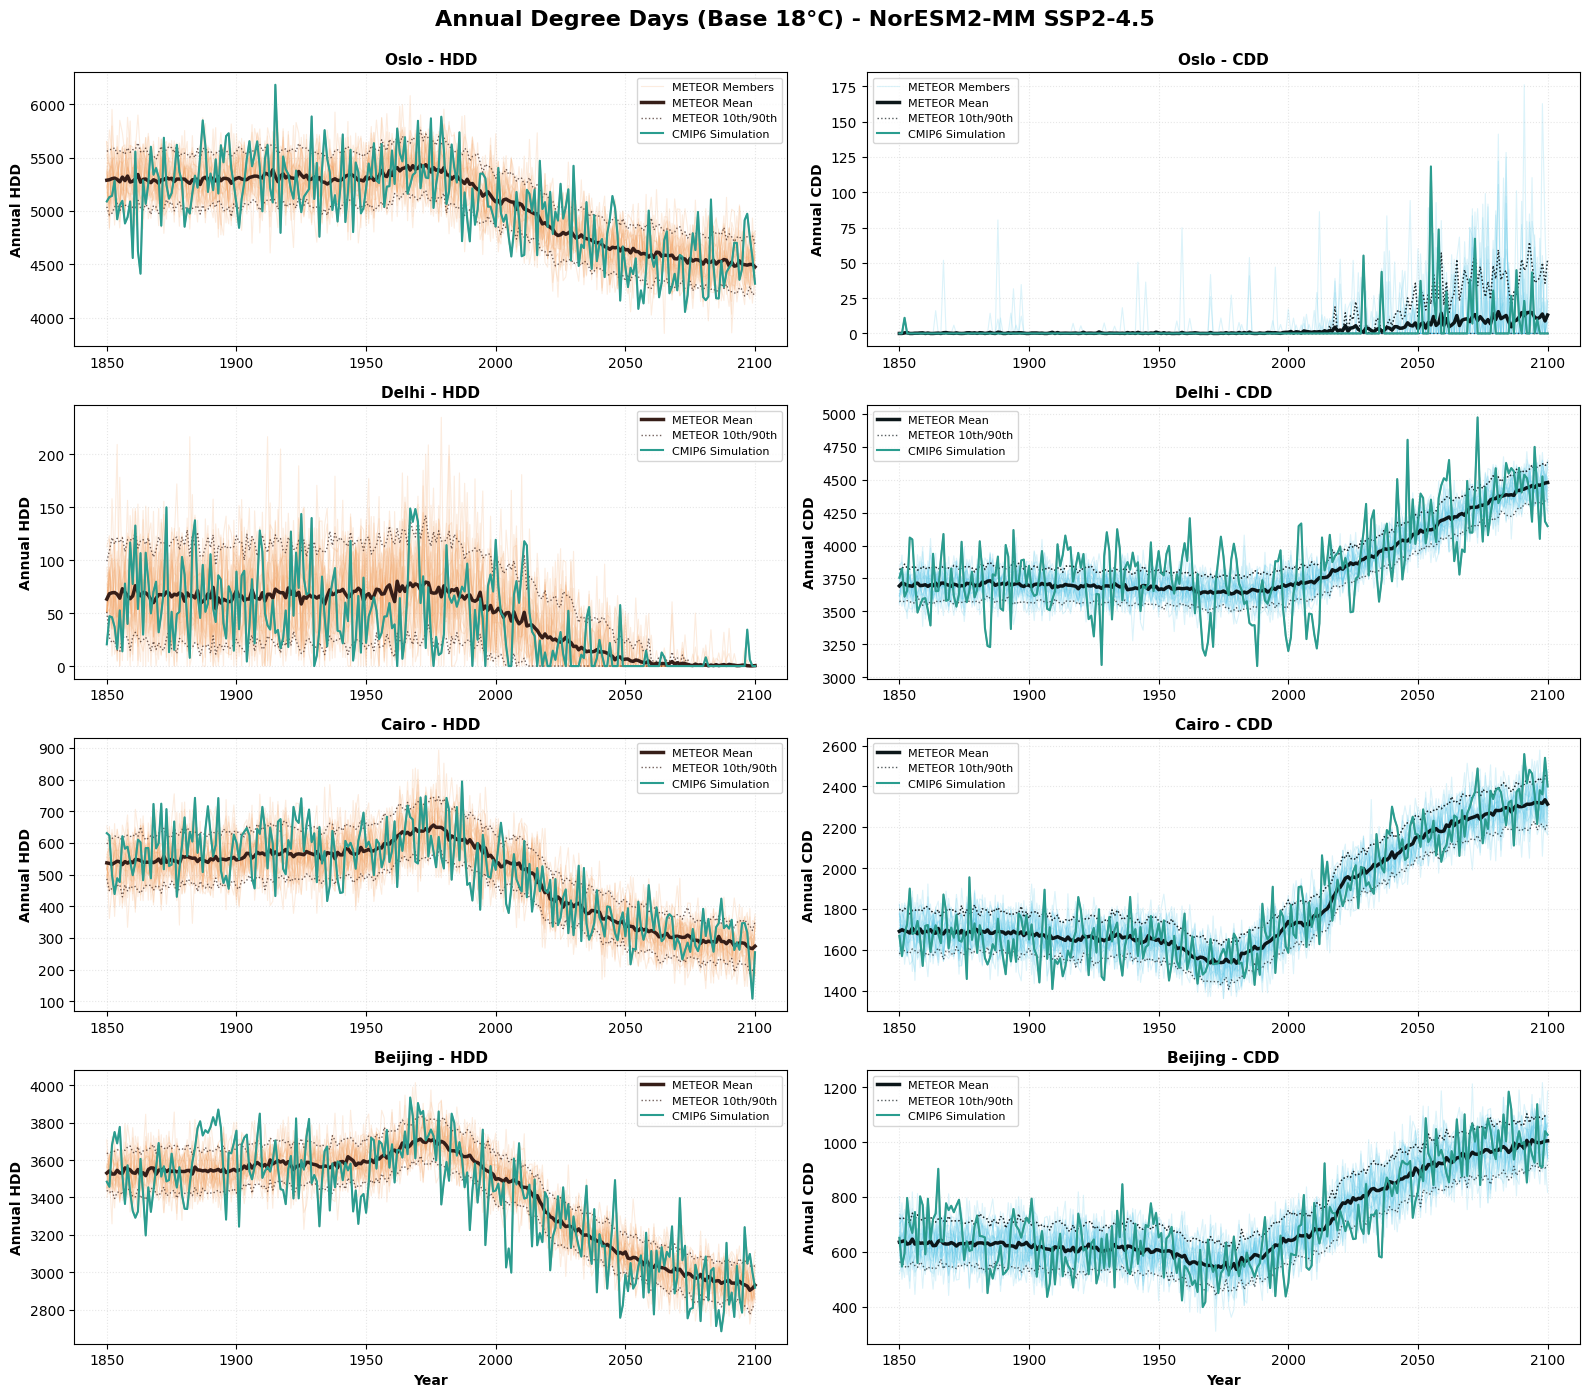


📊 Degree Days Summary (2020 vs 2100):

Heating Degree Days (HDD):
  Oslo        :   5288 →   4475 (-15.4%)
  Delhi       :     63 →      0 (-99.3%)
  Cairo       :    537 →    274 (-49.0%)
  Beijing     :   3531 →   2931 (-17.0%)

Cooling Degree Days (CDD):
  Oslo        :      0 →     13 (+0.0%) | Mean T: -272.5°C
  Delhi       :   3694 →   4478 (+21.2%) | Mean T: -272.6°C
  Cairo       :   1690 →   2313 (+36.8%) | Mean T: -272.6°C
  Beijing     :    635 →   1004 (+58.1%) | Mean T: -272.5°C

   Saved to: ../paper/paper_figures/fig5_degree_days.pdf


In [17]:
# Create 4x2 grid: 4 cities (rows) x 2 metrics (HDD, CDD columns)
fig, axes = plt.subplots(4, 2, figsize=(16, 14))
fig.suptitle('Annual Degree Days (Base 18°C) - NorESM2-MM SSP2-4.5', 
             fontsize=16, fontweight='bold', y=0.995)

city_list = list(cities.keys())

# Get the actual number of years from the HDD data shape
# HDD/CDD are annual values
point_key_test = f"point:{cities[list(cities.keys())[0]]['lat']},{cities[list(cities.keys())[0]]['lon']}"
n_years_emulated = ensemble['tas'].impacts['hdd'][point_key_test].shape[1]
# The ensemble was generated from 1850-2100, so create appropriate time axis
years_annual = 1850 + np.arange(n_years_emulated)

print(f"HDD data shape: {ensemble['tas'].impacts['hdd'][point_key_test].shape}")
print(f"Time range: {years_annual[0]} - {years_annual[-1]}")

for i, city in enumerate(city_list):
    # Build point key
    point_key = f"point:{cities[city]['lat']},{cities[city]['lon']}"
    
    # Get HDD and CDD data (already annual)
    hdd_data = ensemble['tas'].impacts['hdd'][point_key]
    cdd_data = ensemble['tas'].impacts['cdd'][point_key]
    
    # Get temperature data for diagnostic
    tas_data = ensemble['tas'].timeseries[point_key]
    tas_celsius_mean = float(tas_data.mean() - 273.15)
    
    # HDD plot (left column)
    ax_hdd = axes[i, 0]
    
    # Plot emulated ensemble members (only add label for first iteration)
    for j in range(min(20, hdd_data.shape[0])):
        if i == 0 and j == 0:
            ax_hdd.plot(years_annual, hdd_data[j, :], color='#F4A261', alpha=0.2, linewidth=0.8, label='METEOR Members')
        else:
            ax_hdd.plot(years_annual, hdd_data[j, :], color='#F4A261', alpha=0.2, linewidth=0.8)
    
    # Plot emulated ensemble statistics
    hdd_mean = hdd_data.mean(axis=0)
    hdd_p10 = np.percentile(hdd_data, 10, axis=0)
    hdd_p90 = np.percentile(hdd_data, 90, axis=0)
    ax_hdd.plot(years_annual, hdd_mean, color="#361E18", linewidth=2.5, label='METEOR Mean')
    ax_hdd.plot(years_annual, hdd_p10, color='#361E18', linewidth=1, linestyle=':', alpha=0.7, label='METEOR 10th/90th')
    ax_hdd.plot(years_annual, hdd_p90, color='#361E18', linewidth=1, linestyle=':', alpha=0.7)
    
    # Plot CMIP6 original data
    cmip6_hdd_city = cmip6_hdd[city]
    for j in range(cmip6_hdd_city.shape[0]):
        ax_hdd.plot(cmip6_years, cmip6_hdd_city[j, :], color='#264653', alpha=0.4, linewidth=1.2)
    
    # Plot CMIP6 statistics
    cmip6_hdd_mean = cmip6_hdd_city.mean(axis=0)
    cmip6_hdd_p10 = np.percentile(cmip6_hdd_city, 10, axis=0)
    cmip6_hdd_p90 = np.percentile(cmip6_hdd_city, 90, axis=0)
    ax_hdd.plot(cmip6_years, cmip6_hdd_mean, color='#2A9D8F', linewidth=1.5, label='CMIP6 Simulation', linestyle='-')
  
    
    # Calculate trend
    z = np.polyfit(years_annual, hdd_mean, 1)
    trend = z[0] * (2100 - 2020)
    
    ax_hdd.set_title(f"{city} - HDD", 
                     fontsize=11, fontweight='bold')
    ax_hdd.set_ylabel('Annual HDD', fontsize=10, fontweight='bold')
    if i == 3:
        ax_hdd.set_xlabel('Year', fontsize=10, fontweight='bold')
    ax_hdd.grid(True, alpha=0.3, linestyle=':')
    ax_hdd.legend(fontsize=8, loc='best')
    
    # CDD plot (right column)
    ax_cdd = axes[i, 1]
    
    # Plot emulated ensemble members (only add label for first iteration)
    for j in range(min(20, cdd_data.shape[0])):
        if i == 0 and j == 0:
            ax_cdd.plot(years_annual, cdd_data[j, :], color="#51C4E7", alpha=0.2, linewidth=0.8, label='METEOR Members')
        else:
            ax_cdd.plot(years_annual, cdd_data[j, :], color="#51C4E7", alpha=0.2, linewidth=0.8)
    
    # Plot emulated ensemble statistics
    cdd_mean = cdd_data.mean(axis=0)
    cdd_p10 = np.percentile(cdd_data, 10, axis=0)
    cdd_p90 = np.percentile(cdd_data, 90, axis=0)
    ax_cdd.plot(years_annual, cdd_mean, color="#0C1619", linewidth=2.5, label='METEOR Mean')
    ax_cdd.plot(years_annual, cdd_p10, color="#0C1619", linewidth=1, linestyle=':', alpha=0.7, label='METEOR 10th/90th')
    ax_cdd.plot(years_annual, cdd_p90, color="#0C1619", linewidth=1, linestyle=':', alpha=0.7)
    ax_cdd.plot(years_annual, cdd_p90, color="#0C1619", linewidth=1, linestyle=':', alpha=0.7)
    
    # Plot CMIP6 original data
    cmip6_cdd_city = cmip6_cdd[city]
    for j in range(cmip6_cdd_city.shape[0]):
        ax_cdd.plot(cmip6_years, cmip6_cdd_city[j, :], color='#264653', alpha=0.4, linewidth=1.2)
    
    # Plot CMIP6 statistics
    cmip6_cdd_mean = cmip6_cdd_city.mean(axis=0)
    cmip6_cdd_p10 = np.percentile(cmip6_cdd_city, 10, axis=0)
    cmip6_cdd_p90 = np.percentile(cmip6_cdd_city, 90, axis=0)
    ax_cdd.plot(cmip6_years, cmip6_cdd_mean, color='#2A9D8F', linewidth=1.5, label='CMIP6 Simulation', linestyle='-')

    
    # Calculate trend
    z = np.polyfit(years_annual, cdd_mean, 1)
    trend = z[0] * (2100 - 2020)
    
    ax_cdd.set_title(f"{city} - CDD", 
                     fontsize=11, fontweight='bold')
    ax_cdd.set_ylabel('Annual CDD', fontsize=10, fontweight='bold')
    if i == 3:
        ax_cdd.set_xlabel('Year', fontsize=10, fontweight='bold')
    ax_cdd.grid(True, alpha=0.3, linestyle=':')
    ax_cdd.legend(fontsize=8, loc='best')

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'fig5_degree_days.pdf'), bbox_inches='tight', dpi=300)
plt.show()

print("\n📊 Degree Days Summary (2020 vs 2100):")
print("\nHeating Degree Days (HDD):")
for city in city_list:
    point_key = f"point:{cities[city]['lat']},{cities[city]['lon']}"
    hdd_data = ensemble['tas'].impacts['hdd'][point_key]
    
    hdd_2020 = hdd_data[:, 0].mean()  # First year (annual data)
    hdd_2100 = hdd_data[:, -1].mean()  # Last year
    change = ((hdd_2100 - hdd_2020) / hdd_2020) * 100
    
    print(f"  {city:12s}: {float(hdd_2020):6.0f} → {float(hdd_2100):6.0f} ({change:+.1f}%)")

print("\nCooling Degree Days (CDD):")
for city in city_list:
    point_key = f"point:{cities[city]['lat']},{cities[city]['lon']}"
    cdd_data = ensemble['tas'].impacts['cdd'][point_key]
    tas_data = ensemble['tas'].timeseries[point_key]
    
    cdd_2020 = cdd_data[:, 0].mean()  # First year (annual data)
    cdd_2100 = cdd_data[:, -1].mean()  # Last year
    change = ((cdd_2100 - cdd_2020) / cdd_2020) * 100 if cdd_2020 > 0 else 0
    
    # Diagnostic info
    tas_mean_k = float(tas_data.mean())
    tas_mean_c = tas_mean_k - 273.15
    
    print(f"  {city:12s}: {float(cdd_2020):6.0f} → {float(cdd_2100):6.0f} ({change:+.1f}%) | Mean T: {tas_mean_c:.1f}°C")

print(f"\n   Saved to: {os.path.join(FIGURE_DIR, 'fig5_degree_days.pdf')}")

In [18]:
# Summary of all saved figures
import glob

saved_files = sorted(glob.glob(os.path.join(FIGURE_DIR, '*.pdf')))


print(f"\nOutput directory: {os.path.abspath(FIGURE_DIR)}\n")
print(f"Total figures: {len(saved_files)}\n")

for i, filepath in enumerate(saved_files, 1):
    filename = os.path.basename(filepath)
    filesize = os.path.getsize(filepath) / 1024  # KB
    print(f"  {i}. {filename:50s} ({filesize:6.1f} KB)")



Output directory: /Users/bensan/Documents/Github/METEOR/notebooks/paper/paper_figures

Total figures: 29

  1. fig1_comprehensive_projections_2015_2035.pdf       (1139.3 KB)
  2. fig2_regional_projections_2000_2100.pdf            ( 639.1 KB)
  3. fig3_city_projections_1850_2100.pdf                ( 796.4 KB)
  4. fig4_rank_histograms.pdf                           (  34.2 KB)
  5. fig5_degree_days.pdf                               ( 354.8 KB)
  6. fig6_multiscale_tas_CNRM-ESM2-1_validation.pdf     ( 172.3 KB)
  7. fig7_multiscale_pr_CNRM-ESM2-1_validation.pdf      ( 171.8 KB)
  8. fig8_rank_histograms_oslo.pdf                      (  50.6 KB)
  9. fig9_validation_metrics.pdf                        (  29.6 KB)
  10. fig9_validation_metrics_oslo.pdf                   (  33.9 KB)
  11. fig9_validation_metrics_summary_grid.pdf           (  41.5 KB)
  12. fig9_validation_skill_ratio.pdf                    (  49.7 KB)
  13. model_flow.pdf                                     ( 342.0 KB)
  14.

## 10. Out-of-Sample Validation

Test the trained NorESM2-MM model on scenarios it wasn't trained on:
- **SSP1-2.6**: Low emissions scenario
- **SSP5-8.5**: High emissions scenario  
- **SSP5-3.4-OS**: Overshoot scenario

This validates that METEOR can generalize beyond its training data (SSP2-4.5).

In [19]:
# Load CMIP6 data for out-of-sample scenarios
print("Loading CMIP6 data for out-of-sample validation...")
print("Scenarios: SSP1-2.6, SSP5-8.5\n")

# Update the emulator's data getter to include out-of-sample scenarios
# This allows the emulator to generate predictions for scenarios it wasn't trained on
print("Updating emulator data getter to include out-of-sample scenarios...")
emulator.data_getter = Cmip6MeteorDataGetter(
    exps=["piControl", "historical", "ssp245", "abrupt-4xCO2", "ssp126", "ssp585"],
    flds=['tas', 'pr'],
    dbe=['CMIP', 'CMIP', 'ScenarioMIP', 'CMIP', 'ScenarioMIP', 'ScenarioMIP'],
    enable_cache=True
)
print("  ✅ Data getter updated with additional scenarios\n")

# Use the same data getter for loading CMIP6 validation data
oos_data_getter = emulator.data_getter

# Load data for each scenario
oos_scenarios = {
    'ssp126': 'SSP1-2.6',
    'ssp585': 'SSP5-8.5', 
}

cmip6_oos_data = {}
cmip6_oos_timeseries = {}

for scenario_code, scenario_name in oos_scenarios.items():
    print(f"Loading {scenario_name} ({scenario_code})...")
    
    # Load raw CMIP6 data
    cmip6_raw = oos_data_getter.make_meteor_training_data(
        scenario_code, emulator.model, monthly=True
    )
    
    cmip6_oos_data[scenario_code] = cmip6_raw
    
    # Calculate spatial aggregations
    cmip6_oos_timeseries[scenario_code] = {'tas': {}, 'pr': {}}
    
    for variable in ['tas', 'pr']:
        # Global - convert to anomalies for temperature
        cmip6_global = geo_data_utils.global_mean(cmip6_raw[variable])
        if variable == 'tas':
            cmip6_oos_timeseries[scenario_code][variable]['global'] = cmip6_global - picontrol_baselines[variable]['global']
        else:
            cmip6_oos_timeseries[scenario_code][variable]['global'] = cmip6_global
        
        # Regions - convert to anomalies for temperature
        for region in regions:
            cmip6_reg = geo_data_utils.regional_mean(cmip6_raw[variable], region)
            if variable == 'tas':
                cmip6_oos_timeseries[scenario_code][variable][f'regional:{region}'] = cmip6_reg - picontrol_baselines[variable][f'regional:{region}']
            else:
                cmip6_oos_timeseries[scenario_code][variable][f'regional:{region}'] = cmip6_reg
    
    # Extract point data for cities
    for city in cities.keys():
        lat = cities[city]['lat']
        lon = cities[city]['lon']
        point_key = f"point:{lat},{lon}"
        
        # Temperature - convert to anomaly
        picontrol_tas_point = geo_data_utils.extract_point(picontrol_data['tas'], lat, lon)
        baseline_tas = picontrol_tas_point.mean()
        cmip6_tas_point = geo_data_utils.extract_point(cmip6_raw['tas'], lat, lon)
        
        if 'tas' not in cmip6_oos_timeseries[scenario_code]:
            cmip6_oos_timeseries[scenario_code]['tas'] = {}
        cmip6_oos_timeseries[scenario_code]['tas'][point_key] = cmip6_tas_point - baseline_tas
        
        # Precipitation - no anomaly
        cmip6_pr_point = geo_data_utils.extract_point(cmip6_raw['pr'], lat, lon)
        if 'pr' not in cmip6_oos_timeseries[scenario_code]:
            cmip6_oos_timeseries[scenario_code]['pr'] = {}
        cmip6_oos_timeseries[scenario_code]['pr'][point_key] = cmip6_pr_point
    
    print(f"  ✅ {scenario_name} loaded - TAS shape: {cmip6_raw['tas'].shape}, PR shape: {cmip6_raw['pr'].shape}")

print(f"\n✅ All out-of-sample CMIP6 data loaded")
print(f"   Scenarios: {len(oos_scenarios)}")
print(f"   Spatial aggregations per scenario: {len(timeseries)}")

Loading CMIP6 data for out-of-sample validation...
Scenarios: SSP1-2.6, SSP5-8.5

Updating emulator data getter to include out-of-sample scenarios...
  ✅ Data getter updated with additional scenarios

Loading SSP1-2.6 (ssp126)...
  ✅ SSP1-2.6 loaded - TAS shape: (1, 1032, 192, 288), PR shape: (1, 1032, 192, 288)
Loading SSP5-8.5 (ssp585)...
  ✅ SSP5-8.5 loaded - TAS shape: (1, 1032, 192, 288), PR shape: (1, 1032, 192, 288)

✅ All out-of-sample CMIP6 data loaded
   Scenarios: 2
   Spatial aggregations per scenario: 8


In [20]:
# Generate METEOR predictions for out-of-sample scenarios
print("Generating METEOR predictions for out-of-sample scenarios...")

oos_ensembles = {}

for scenario_code, scenario_name in oos_scenarios.items():
    print(f"\nGenerating ensemble for {scenario_name} ({scenario_code})...")
    
    # Generate ensemble using the trained model
    oos_ensemble = emulator.generate_ensemble_outputs(
        scenario=scenario_code,
        start_year=2015,
        end_year=2100,
        n_realizations=100,
        timeseries=timeseries,
        verbose=False
    )
    
    oos_ensembles[scenario_code] = oos_ensemble
    
    print(f"  ✅ {scenario_name} ensemble generated")
    print(f"     Variables: {oos_ensemble.list_variables()}")
    print(f"     TAS timeseries: {len(oos_ensemble['tas'].timeseries)}")
    print(f"     PR timeseries: {len(oos_ensemble['pr'].timeseries)}")

print(f"\n✅ All out-of-sample predictions complete")

# Create time axis for out-of-sample data (2015-2100)
n_months_oos = oos_ensembles['ssp126']['tas'].timeseries['global'].shape[1]
years_oos = 2015 + np.arange(n_months_oos) / 12
print(f"   Time range: {years_oos[0]:.0f} - {years_oos[-1]:.0f}")
print(f"   Ensemble size: 100 realizations per scenario")

Generating METEOR predictions for out-of-sample scenarios...

Generating ensemble for SSP1-2.6 (ssp126)...
  ✅ SSP1-2.6 ensemble generated
     Variables: ['tas', 'pr']
     TAS timeseries: 8
     PR timeseries: 8

Generating ensemble for SSP5-8.5 (ssp585)...
  ✅ SSP5-8.5 ensemble generated
     Variables: ['tas', 'pr']
     TAS timeseries: 8
     PR timeseries: 8

✅ All out-of-sample predictions complete
   Time range: 2015 - 2101
   Ensemble size: 100 realizations per scenario


In [21]:
# Create CMIP6 time axis for out-of-sample scenarios
n_months_cmip6_oos = cmip6_oos_data['ssp126']['tas'].shape[1]
years_cmip6_oos = 2015 + np.arange(n_months_cmip6_oos) / 12

print(f"CMIP6 out-of-sample time range: {years_cmip6_oos[0]:.0f} - {years_cmip6_oos[-1]:.0f}")
print(f"CMIP6 data shape: {cmip6_oos_data['ssp126']['tas'].shape}")

CMIP6 out-of-sample time range: 2015 - 2101
CMIP6 data shape: (1, 1032, 192, 288)


### Out-of-Sample Validation Plot

Compare METEOR predictions against actual CMIP6 data for scenarios not used in training.

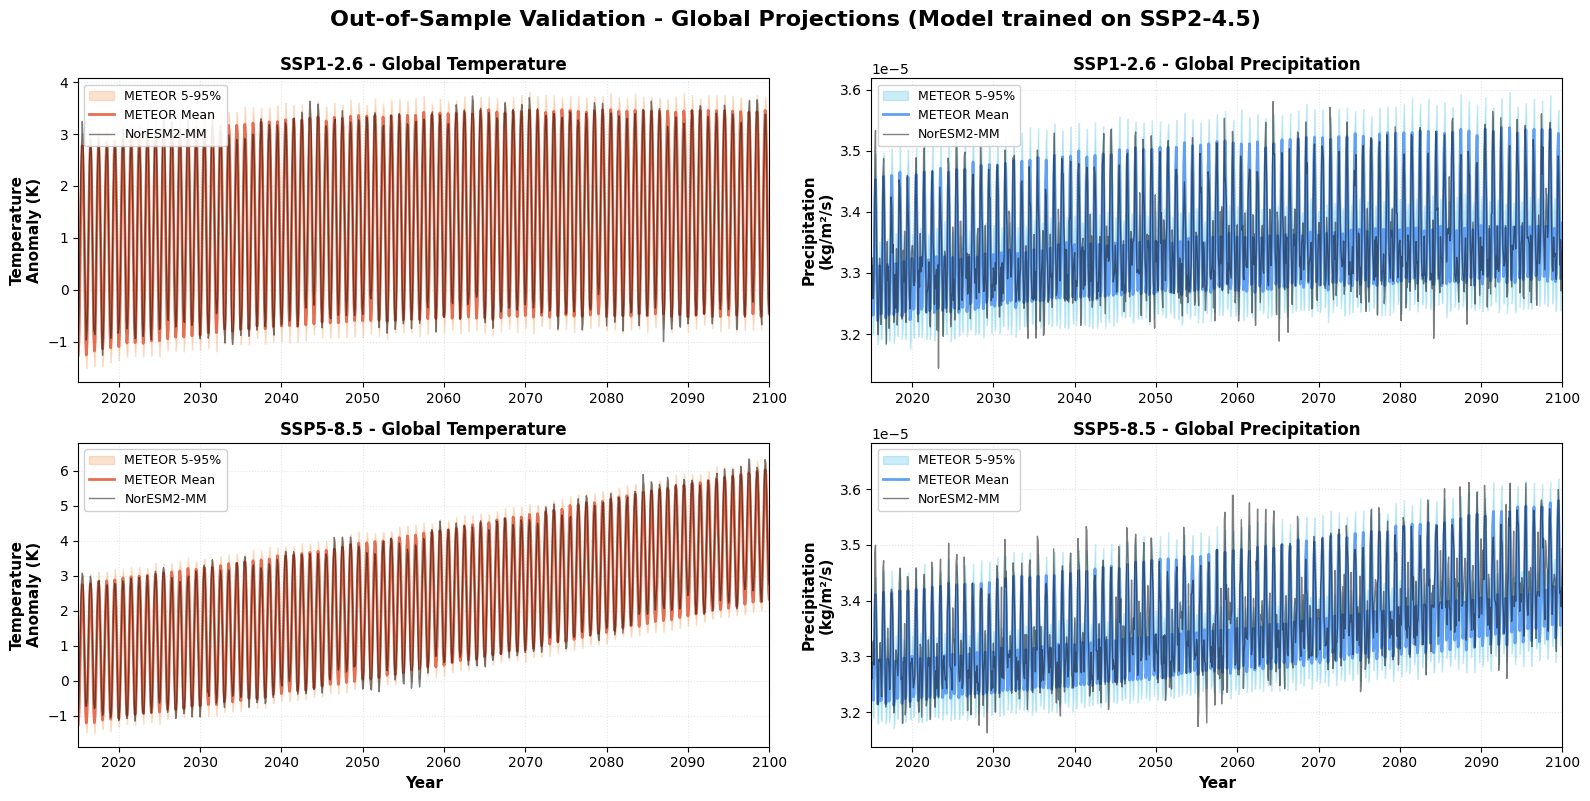

✅ Out-of-sample validation plot complete
   Saved to: ../paper/paper_figures/fig6_out_of_sample_global.pdf


In [22]:
# Plot out-of-sample validation: 2 scenarios x 2 variables (temp, precip) for global
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
fig.suptitle('Out-of-Sample Validation - Global Projections (Model trained on SSP2-4.5)', 
             fontsize=16, fontweight='bold', y=0.995)

for i, (scenario_code, scenario_name) in enumerate(oos_scenarios.items()):
    # Get METEOR data
    tas_data = oos_ensembles[scenario_code]['tas'].timeseries['global']
    pr_data = oos_ensembles[scenario_code]['pr'].timeseries['global']
    
    # Get CMIP6 data
    cmip6_tas = cmip6_oos_timeseries[scenario_code]['tas']['global']
    cmip6_pr = cmip6_oos_timeseries[scenario_code]['pr']['global']
    
    # === Temperature (left column) ===
    ax_t = axes[i, 0]
    
    # Calculate percentiles and mean
    tas_p5 = np.percentile(tas_data, 5, axis=0)
    tas_p95 = np.percentile(tas_data, 95, axis=0)
    tas_mean = tas_data.mean(axis=0)
    
    # Plot METEOR predictions with consistent temperature colors
    ax_t.fill_between(years_oos, tas_p5, tas_p95, color='#F4A261', alpha=0.3, label='METEOR 5-95%')
    ax_t.plot(years_oos, tas_mean, color='#E76F51', linewidth=2, label='METEOR Mean')
    
    # Plot CMIP6 data
    if cmip6_tas.ndim == 2:
        cmip6_tas_mean = cmip6_tas.mean(dim='ens')
        ax_t.plot(years_cmip6_oos, cmip6_tas_mean, color='black', linestyle='-', linewidth=1, 
                 label='NorESM2-MM', zorder=10, alpha=0.5)
    else:
        ax_t.plot(years_cmip6_oos, cmip6_tas, color='black', linestyle='-', linewidth=1, 
                 label='NorESM2-MM', zorder=10, alpha=0.5)
    
    ax_t.set_ylabel('Temperature\nAnomaly (K)', fontsize=11, fontweight='bold')
    ax_t.set_title(f'{scenario_name} - Global Temperature', fontsize=12, fontweight='bold')
    ax_t.grid(True, alpha=0.3, linestyle=':')
    leg = ax_t.legend(fontsize=9, loc='upper left', framealpha=0.9)
    leg.set_zorder(100)
    ax_t.set_xlim([2015, 2100])
    
    if i == 1:
        ax_t.set_xlabel('Year', fontsize=11, fontweight='bold')
    
    # === Precipitation (right column) ===
    ax_p = axes[i, 1]
    
    # Calculate percentiles and mean
    pr_p5 = np.percentile(pr_data, 5, axis=0)
    pr_p95 = np.percentile(pr_data, 95, axis=0)
    pr_mean = pr_data.mean(axis=0)
    
    # Plot METEOR predictions with consistent precipitation colors
    ax_p.fill_between(years_oos, pr_p5, pr_p95, color='#51C4E7', alpha=0.3, label='METEOR 5-95%')
    ax_p.plot(years_oos, pr_mean, color='#61A1F4', linewidth=2, label='METEOR Mean')
    
    # Plot CMIP6 data
    if cmip6_pr.ndim == 2:
        cmip6_pr_mean = cmip6_pr.mean(dim='ens')
        ax_p.plot(years_cmip6_oos, cmip6_pr_mean, color='black', linestyle='-', linewidth=1, 
                 label='NorESM2-MM', zorder=10, alpha=0.5)
    else:
        ax_p.plot(years_cmip6_oos, cmip6_pr, color='black', linestyle='-', linewidth=1, 
                 label='NorESM2-MM', zorder=10, alpha=0.5)
    
    ax_p.set_ylabel('Precipitation\n(kg/m²/s)', fontsize=11, fontweight='bold')
    ax_p.set_title(f'{scenario_name} - Global Precipitation', fontsize=12, fontweight='bold')
    ax_p.grid(True, alpha=0.3, linestyle=':')
    leg = ax_p.legend(fontsize=9, loc='upper left', framealpha=0.9)
    leg.set_zorder(100)
    ax_p.set_xlim([2015, 2100])
    
    if i == 1:
        ax_p.set_xlabel('Year', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'fig6_out_of_sample_global.pdf'), bbox_inches='tight', dpi=300)
plt.show()

print(f"✅ Out-of-sample validation plot complete")
print(f"   Saved to: {os.path.join(FIGURE_DIR, 'fig6_out_of_sample_global.pdf')}")